# Week 7 Phase 3 — new-data physical-response model stability / replication

This notebook asks one bounded question:

> **Do the Week 6 physical-response modelling conclusions survive when the same scientific pipeline is evaluated independently on Ioan's newly generated simulation design?**

The primary domain is `partition == "new-data"`. Old and new simulations are never pooled. The immutable dataset is `ioandanielc/sph_v2@d69dac5bda8b622bc0de316b112815c6056c06ec`, and the repository starting point is `codex/week7-phase1-2-sph-v2-audit@f26f0671dd59938a8111883398fe38afedb6915d`.

```text
Week 7 Phase 3
├── immutable provenance and readiness-derived population
├── executable Week 6 protocol traceability
├── exact simulation-level LOO baselines and Gaussian processes
├── numerical-jitter / shared-nugget / heteroskedastic-alpha comparison
├── median-scale relative errors and calibration
├── saved Week 6 versus new-data replication evidence
└── validation and hard stop before later Week 7 phases
```

Scope boundary: no Keyhole or extreme-event classifier, feature-effect or causal analysis, target redesign, active learning, level-set estimation, or pooled production model is created here.

## 1. Scope and immutable data provenance

**What are we doing?** Load the full saved Phase 3 artifacts and verify their revision, branch base, and hard-stop flags.  
**Why?** A current remote branch head and one immutable `sph_v2` snapshot are prerequisites for a meaningful replication.  
**What question does this answer?** Did this analysis use the corrected Phase 2 dataset rather than a floating Hugging Face main or stale branch?  
**What would be suspicious?** Any revision mismatch, pooled-population flag, later-phase scope flag, or missing source hash.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
OUT = ROOT / "outputs" / "week7_03_new_data_physical_model_stability"
P2 = ROOT / "outputs" / "week7_02_sph_v2_target_extraction"
assert ROOT.name == "thesis-week7-phase3-new-data-model-stability"

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 110)

summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
configuration = json.loads((OUT / "phase3_configuration.json").read_text(encoding="utf-8"))
provenance = json.loads((OUT / "input_provenance.json").read_text(encoding="utf-8"))
assert summary["mode"] == "full"
assert summary["dataset_revision"] == "d69dac5bda8b622bc0de316b112815c6056c06ec"
assert summary["starting_remote_head_sha"] == "f26f0671dd59938a8111883398fe38afedb6915d"
assert not any(configuration["scope"].values())
display(pd.DataFrame({
    "item": ["starting branch", "starting SHA", "dataset", "revision", "old/new pooled", "later phases run"],
    "value": [summary["starting_branch"], summary["starting_remote_head_sha"], summary["dataset_repo_id"],
              summary["dataset_revision"], summary["scope"]["old_new_pooled"], summary["scope"]["later_week7_phases"]],
}))
display(provenance)

,item,value
0,starting branch,codex/week7-phase1-2-sph-v2-audit
1,starting SHA,f26f0671dd59938a8111883398fe38afedb6915d
2,dataset,ioandanielc/sph_v2
3,revision,d69dac5bda8b622bc0de316b112815c6056c06ec
4,old/new pooled,False
5,later phases run,False


{'starting_remote_head_sha': 'f26f0671dd59938a8111883398fe38afedb6915d',
 'dataset_repo_id': 'ioandanielc/sph_v2',
 'dataset_revision': 'd69dac5bda8b622bc0de316b112815c6056c06ec',
 'phase2_target_csv': 'outputs/week7_02_sph_v2_target_extraction/sph_v2_simulation_level_targets.csv',
 'phase2_target_csv_sha256': 'bd63d25911e9d172bb6e299fa7c4c3d19539225a423f86db093ebf33f94585e2',
 'phase2_target_parquet': 'outputs/week7_02_sph_v2_target_extraction/sph_v2_simulation_level_targets.parquet',
 'phase2_target_parquet_sha256': 'a3d572ab45553e049702dfdd6c0fe587dc9a1dc0d058f0bf5c0768b89705fdc3',
 'phase2_summary_sha256': '4af631de90df0692b3664b4bc7ee35eea8a2b3861e2eada339d4102d5a7dbb97',
 'phase2_summary_revision': 'd69dac5bda8b622bc0de316b112815c6056c06ec',
 'target_values_recalculated': False,
 'raw_monitor_use': 'Method C target-summary uncertainty only; Phase 2 target medians reproduced and verified'}

**What did we observe?** The full run is tied to the exact corrected Phase 2 revision and the verified current remote Week 7 head. All later-phase and pooled-analysis scope flags are false.

## 2. New-data model-ready population

**What are we doing?** Re-derive each target's eligibility directly from its saved Phase 2 readiness fields while retaining the complete label/audit table.  
**Why?** The genuinely monitor-incomplete experiment must remain auditable but must not receive a fabricated physical response.  
**What question does this answer?** How many new-data experiments are eligible for each target, and was any identifier exclusion list needed?  
**What would be suspicious?** A hard-coded count or experiment name, a dropped audit row, an old-data row, or a finite invented target for an unavailable monitor.

In [2]:
population = pd.read_csv(OUT / "model_ready_population.csv")
population_long = pd.read_csv(OUT / "model_ready_population_long.csv")
target_specs = configuration["primary_targets"]
rows = []
for target, spec in target_specs.items():
    eligible = pd.Series(True, index=population.index)
    for field in spec["eligibility_fields"]:
        eligible &= population[field].astype(bool)
    eligible &= pd.to_numeric(population[spec["phase2_column"]], errors="coerce").notna()
    assert eligible.equals(population[f"{target}_model_eligible"].astype(bool))
    rows.append({"target": target, "audit_n": len(population), "eligible_n": int(eligible.sum()),
                 "ineligible_n": int((~eligible).sum()), "eligibility_fields": ", ".join(spec["eligibility_fields"])})
assert set(population["partition"]) == {"new-data"}
assert set(population_long["partition"]) == {"new-data"}
display(pd.DataFrame(rows))
display(population.loc[~population["physical_target_extraction_success"].astype(bool),
    ["experiment_name", "partition", "extraction_failure_reasons", "physical_target_extraction_success"]])

,target,audit_n,eligible_n,ineligible_n,eligibility_fields
0,width,165,164,1,"geometry_monitor_available, geometry_parse_ok, geometry_target_ready, time_monitor_available, time_parse_o..."
1,depth,165,164,1,"geometry_monitor_available, geometry_parse_ok, geometry_target_ready, time_monitor_available, time_parse_o..."
2,total_height,165,164,1,"geometry_monitor_available, geometry_parse_ok, geometry_target_ready, time_monitor_available, time_parse_o..."
3,kinetic_energy,165,164,1,"geometry_monitor_available, geometry_parse_ok, geometry_target_ready, time_monitor_available, time_parse_o..."


,experiment_name,partition,extraction_failure_reasons,physical_target_extraction_success
44,P-204p165012598_VX-0p624752635414_LS-8p54709329997e-05_ST-334p626206985_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,new-data,missing kinetic-energy_melt.dat; missing position-bounds_melt.dat,False


**What did we observe?** All 165 new-data rows remain in the audit interface; readiness flags yield {'width': 164, 'depth': 164, 'total_height': 164, 'kinetic_energy': 164} eligible physical-response experiments. The incomplete row is explicit and is absent only from model-ready response rows.

## 3. Week 6 modelling traceability

**What are we doing?** Inspect a method-by-method table generated from the actual Week 6 source functions and configuration artifacts.  
**Why?** The scientific intervention is a new population, not a new modelling protocol.  
**What question does this answer?** Which implementation, settings, bounds, normalization, optimizers, seeds, and evaluation rules were reused or necessarily changed?  
**What would be suspicious?** A setting recalled from memory, an unrecorded hyperparameter search, new kernel, or random split.

In [3]:
traceability = pd.read_csv(OUT / "week6_model_traceability.csv")
display(traceability[["week6_model_method", "source_file", "source_function_class",
                      "important_settings", "phase3_reuse_change", "reason"]])
assert traceability["phase3_reuse_change"].str.contains("reuse", case=False).any()
assert configuration["outer_evaluation"] == "exact simulation-level leave-one-out"


,week6_model_method,source_file,source_function_class,important_settings,phase3_reuse_change,reason
0,Training-fold mean predictor,src/week6_phase3_model_target_robustness.py,run_training_mean_loo,Exact simulation-level LOO; mean computed from outer-training targets only,Reused exactly on each new-data target population,"Change the population, not the baseline protocol"
1,Linear Ridge,src/week6_phase3_model_target_robustness.py,_make_ridge_regressor; _fit_ridge_fold; run_ridge_loo,Fold-local StandardScaler(X); fold-local StandardScaler(y) through TransformedTargetRegressor; alpha=1e-6....,Reused exactly,Preserve Week 6 leakage controls and tuning grid
2,Polynomial Ridge degree 2,src/week6_phase3_model_target_robustness.py,_make_ridge_regressor; _fit_ridge_fold; run_ridge_loo,"StandardScaler(X) -> PolynomialFeatures(degree=2, include_bias=False) -> StandardScaler(polynomial terms) ...",Reused exactly; no higher polynomial degree,Preserve the Week 6 nonlinear simple baseline
3,GP kernel comparison,src/week6_phase3_model_target_robustness.py,GPConfiguration; make_gp_kernel; _fit_gp_fold; run_gp_loo,ConstantKernel*(RBF or isotropic Matérn 3/2 or Matérn 5/2); constant bounds 1e-3..1e3; lengthscale bounds ...,All six kernel x nugget configurations reused exactly,Direct model-ranking replication on the shifted design
4,A: numerical jitter / deterministic treatment,src/week6_phase2_gp_response_noise_comparison.py; src/week6_phase3_model_target_robustness.py,make_kernel; _fit_loo_fold; GPConfiguration,No WhiteKernel; alpha=1e-6 in normalized target units; predictive variance is latent variance,Reused through the final Week 6 Phase 3 GP engine,Same covariance and numerical treatment used in the final Week 6 kernel matrix
5,B: shared learned nugget,src/week6_phase2_gp_response_noise_comparison.py; src/week6_phase3_model_target_robustness.py,make_kernel; _fit_loo_fold; GPConfiguration,"WhiteKernel initial variance 1e-2, bounds 1e-8..1e1; numerical alpha=1e-8; total predictive variance evalu...",Reused exactly,Test whether the effective residual term remains useful; it is not interpreted as simulator noise
6,C: heteroskedastic target-summary alpha,src/week6_phase2_gp_response_noise_comparison.py,block_length_rule; moving_block_bootstrap_medians; _fit_loo_fold,"500 circular moving-block bootstrap medians; block=max(5,round(n_window^(1/3))); alpha_i=bootstrap_varianc...",Exact bootstrap and alpha formulas reused on Phase 2-saved T0 row indices; response series are read from p...,Phase 2 stores T0 targets and row indices but not the Week 6 block-bootstrap variance artifact
7,Outer evaluation and probabilistic metrics,src/week6_phase2_gp_response_noise_comparison.py; src/week6_phase3_model_target_robustness.py,_fit_loo_fold; _fit_gp_fold; gaussian_nlpd; point_metric_row; gp_metric_row,"Exact simulation-level LOO; held-out observation excluded from scaling/tuning/fitting; MAE, RMSE, R2, NLPD...",Reused; median-scale relative MAE/RMSE added as requested,Ioan requested interpretable percentage errors without unstable pointwise MAPE
8,Total-height and kinetic-energy compact comparison,src/week6_phase4_new_outputs_feature_effects.py,load_phase3_engine; model_table_for_response; run_models; select_final_models,"Phase 4 imports the validated Phase 3 LOO engine; Mean, Linear Ridge, degree-2 Polynomial Ridge, three lea...",Same Phase 3 engine applied uniformly to all four primary responses; all no-nugget kernels retained for th...,Unifies the historical width/depth and total-height/energy comparisons without changing their model protocol


**What did we observe?** The executable Week 6 preprocessing, target normalization, nested Ridge selection, GP kernels/bounds, L-BFGS-B optimizer, deterministic seeds, and LOO evaluation are reused. Smoke-only reductions are not present in this full run.

## 4. Target scales and descriptive context

**What are we doing?** Summarize the four saved Phase 2 T0 target distributions and their median absolute scales.  
**Why?** Absolute errors cannot be interpreted across shifted designs or physical units without target-scale context.  
**What question does this answer?** What denominators will anchor the required relative MAE and RMSE percentages?  
**What would be suspicious?** A recomputed T0, maximum response substituted for T0, zero denominator, or mixed units.

,target,target_label,target_unit,n,minimum,median,mean,maximum,std,median_abs_denominator
0,depth,T0 penetration depth,um,164,26.909320,74.741470,104.539754,300.529900,73.040791,74.741470
1,kinetic_energy,T0 melt kinetic energy,nJ,164,0.733964,3.349977,3.440343,8.876052,1.705074,3.349977
2,total_height,T0 total vertical melt-pool height,um,164,51.444150,100.628758,128.880788,322.614550,71.140331,100.628758
3,width,T0 melt-pool width,um,164,111.529485,166.656785,171.418665,300.269850,36.546741,166.656785


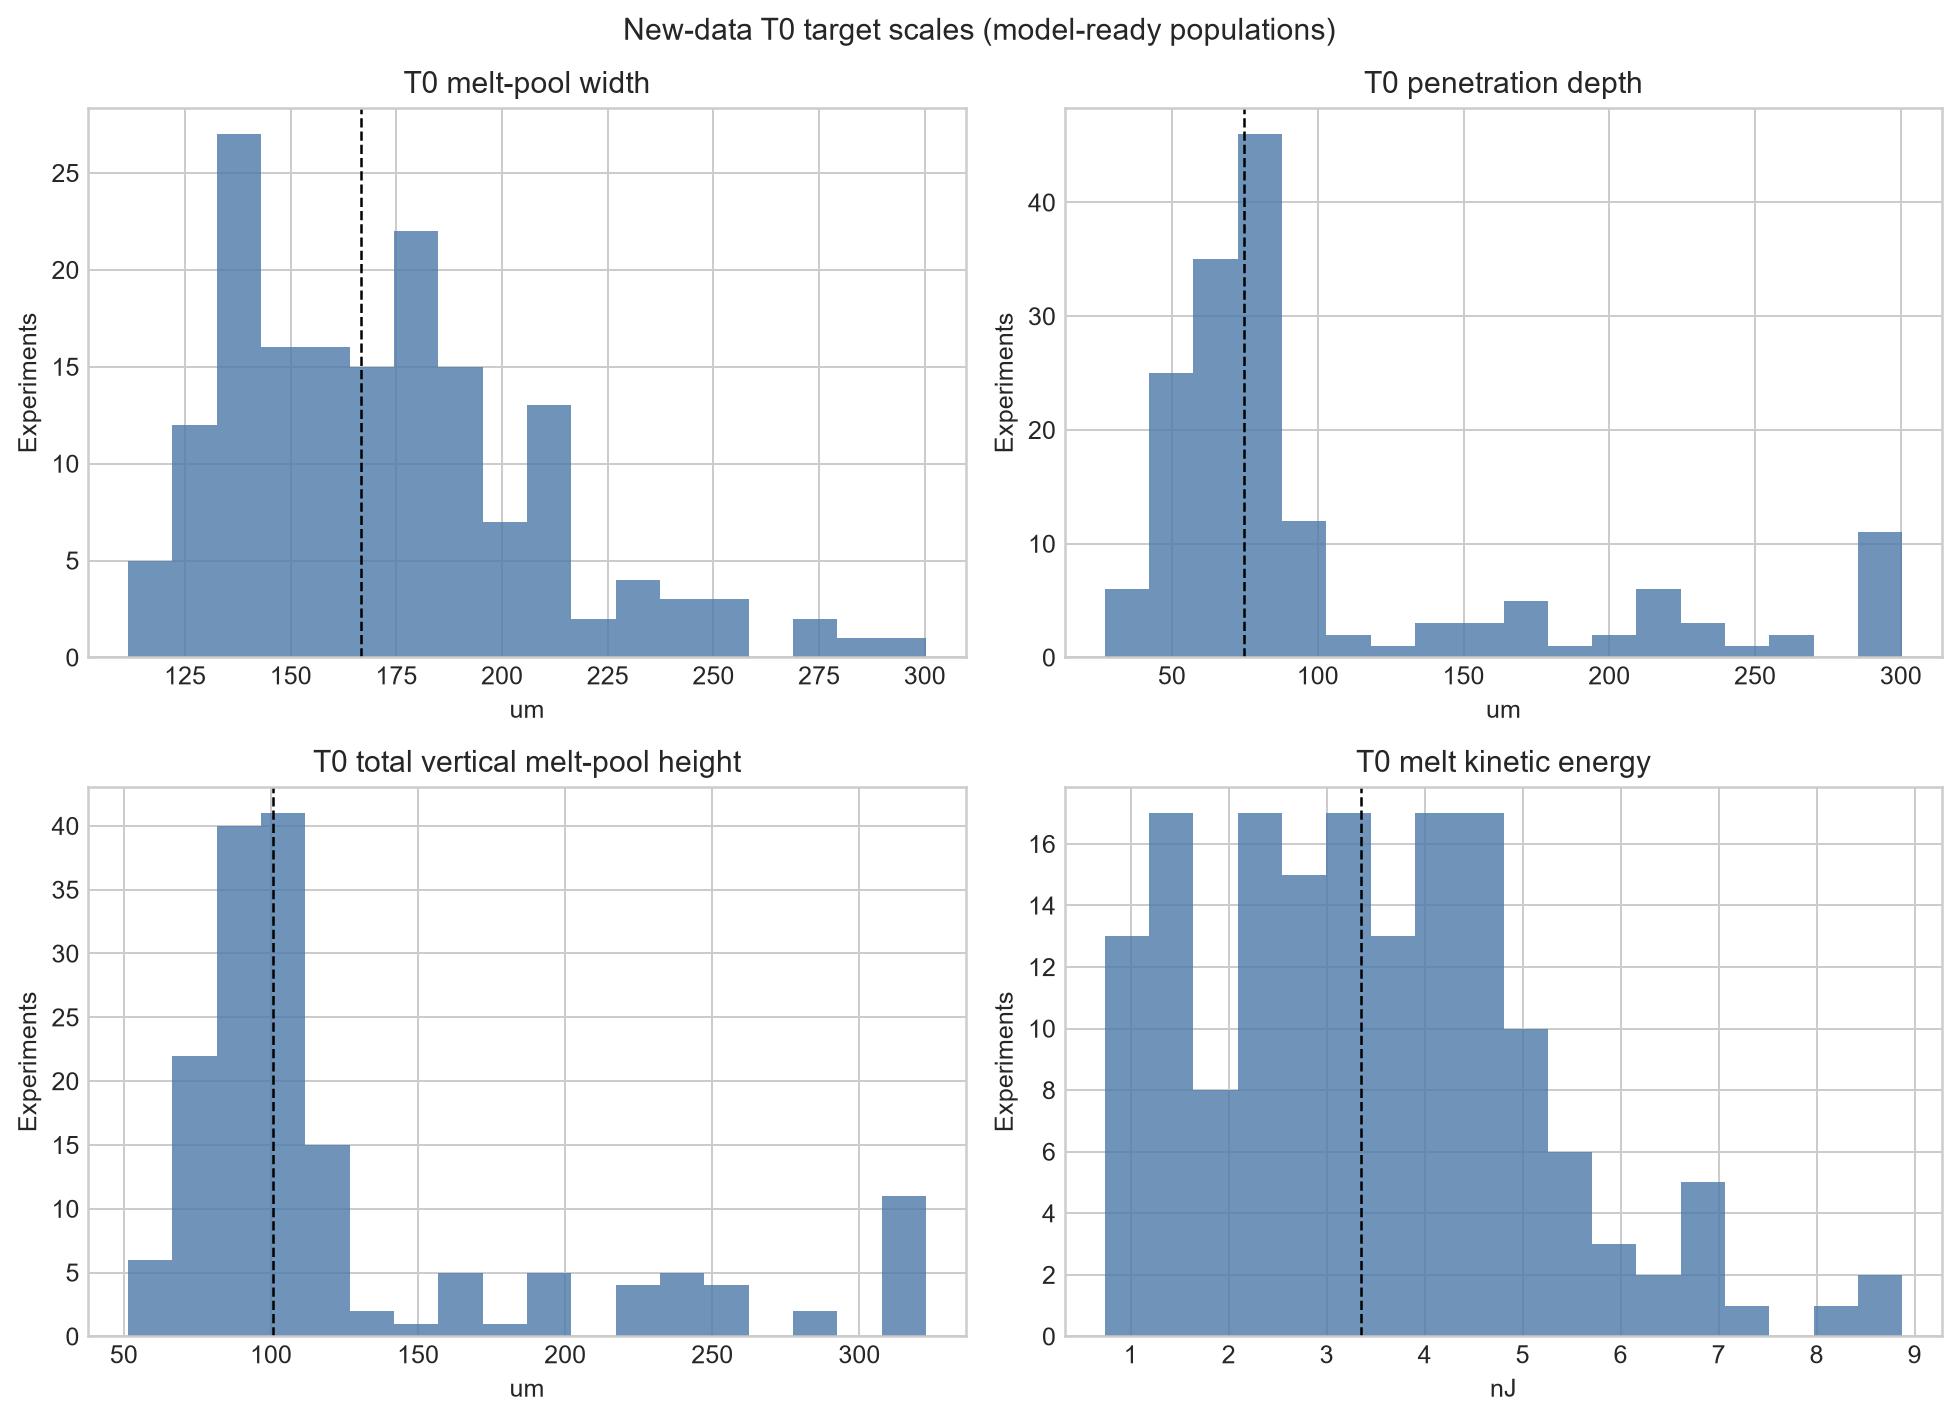

In [4]:
scale_table = (population_long.groupby(["target", "target_label", "target_unit"])["target_value_um"]
    .agg(n="size", minimum="min", median="median", mean="mean", maximum="max", std="std").reset_index())
scale_table["median_abs_denominator"] = population_long.groupby("target")["target_value_um"].apply(lambda x: np.median(np.abs(x))).values
display(scale_table)
display(Image(filename=str(OUT / "figures" / "01_new_data_target_scales.png"), width=920))

**What did we observe?** The target distributions and units differ substantially, so the remainder reports both native-unit errors and percentages of `median(abs(y_observed))`. No maximum, G3, or R3 response is promoted.

## 5. Mean / Linear Ridge / Polynomial Ridge baselines

**What are we doing?** Recompute baseline MAE and RMSE visibly from the held-out rows and compare them with the stored aggregate table.  
**Why?** This verifies that the GP is judged against meaningful simple surfaces under the identical outer folds.  
**What question does this answer?** Does a smooth nonlinear GP add value beyond a training mean, linear response, or degree-2 polynomial approximation?  
**What would be suspicious?** Feature or polynomial leakage, a held-out target used in inner tuning, or aggregate metrics that do not reconcile.

In [5]:
pred = pd.read_csv(OUT / "fold_level_predictions.csv")
metrics = pd.read_csv(OUT / "model_metric_table.csv")
baseline_names = ["training_mean", "linear_ridge", "polynomial_ridge_degree2"]
baseline_pred = pred[pred["model"].isin(baseline_names)].copy()
recomputed = (baseline_pred.groupby(["target", "model"])
    .apply(lambda g: pd.Series({
        "n": len(g),
        "MAE_from_folds": np.mean(np.abs(g["observed_target_value"] - g["predicted_mean"])),
        "RMSE_from_folds": np.sqrt(np.mean((g["observed_target_value"] - g["predicted_mean"])**2)),
        "heldout_used_for_tuning": g["heldout_target_used_for_tuning"].astype(bool).any(),
    }), include_groups=False).reset_index())
stored = metrics[metrics["model"].isin(baseline_names)][["target", "model", "MAE", "RMSE", "relative_RMSE_pct", "R2"]]
check = recomputed.merge(stored, on=["target", "model"], validate="one_to_one")
assert np.allclose(check["MAE_from_folds"], check["MAE"])
assert np.allclose(check["RMSE_from_folds"], check["RMSE"])
assert not check["heldout_used_for_tuning"].any()
display(check.sort_values(["target", "RMSE"]))

C:\Users\ozgur\AppData\Local\Temp\ipykernel_3000\2033491754.py:1: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  pred = pd.read_csv(OUT / "fold_level_predictions.csv")


,target,model,n,MAE_from_folds,RMSE_from_folds,heldout_used_for_tuning,MAE,RMSE,relative_RMSE_pct,R2
1,depth,polynomial_ridge_degree2,164,22.588772,33.603820,False,22.588772,33.603820,44.960074,0.787038
0,depth,linear_ridge,164,32.741649,43.258084,False,32.741649,43.258084,57.876950,0.647093
2,depth,training_mean,164,55.847337,73.264499,False,55.847337,73.264499,98.023894,-0.012308
4,kinetic_energy,polynomial_ridge_degree2,164,0.437324,0.678717,False,0.437324,0.678717,20.260339,0.840579
3,kinetic_energy,linear_ridge,164,0.449039,0.730832,False,0.449039,0.730832,21.816037,0.815156
5,kinetic_energy,training_mean,164,1.386364,1.710296,False,1.386364,1.710296,51.053972,-0.012308
7,total_height,polynomial_ridge_degree2,164,23.229344,34.242113,False,23.229344,34.242113,34.028158,0.766898
6,total_height,linear_ridge,164,33.167686,44.516669,False,33.167686,44.516669,44.238516,0.606024
8,total_height,training_mean,164,54.231745,71.358219,False,54.231745,71.358219,70.912352,-0.012308
10,width,polynomial_ridge_degree2,164,3.240673,4.299549,False,3.240673,4.299549,2.579883,0.986075


**What did we observe?** Each baseline has one simulation-level held-out prediction per eligible experiment. Scaling, polynomial construction, y normalization, and inner alpha selection are recorded as outer-training-only, and aggregate errors reconcile exactly.

## 6. GP kernel comparison

**What are we doing?** Rank the learned-nugget RBF, Matérn 3/2, and Matérn 5/2 candidates by held-out error, while retaining the Week 6 paired replacement rule.  
**Why?** A raw minimum alone can be too fragile to justify changing a previously selected kernel.  
**What question does this answer?** Does Matérn 3/2 remain the strongest protocol choice for each physical response?  
**What would be suspicious?** A new kernel, large unplanned search, ranking based on training likelihood, or hidden convergence failures.

In [6]:
kernels = pd.read_csv(OUT / "kernel_comparison.csv")
decisions = pd.read_csv(OUT / "model_selection_decisions.csv")
display(kernels[["target", "model", "kernel", "n", "MAE", "RMSE", "relative_RMSE_pct", "R2",
                 "NLPD", "coverage_95", "fit_failures", "warnings", "bound_hit_fraction"]])
display(decisions[["target", "best_learned_nugget_gp_by_RMSE", "protocol_selected_gp", "kernel_replacement_rationale"]])

,target,model,kernel,n,MAE,RMSE,relative_RMSE_pct,R2,NLPD,coverage_95,fit_failures,warnings,bound_hit_fraction
0,depth,matern32_learned_nugget,Matérn 3/2,164,11.937466,21.808185,29.178159,0.910306,4.409518,0.920732,0,0,0.0
1,depth,matern52_learned_nugget,Matérn 5/2,164,12.284334,21.903858,29.306164,0.909517,4.417572,0.920732,0,0,0.0
2,depth,rbf_learned_nugget,RBF,164,13.369960,22.516323,30.125610,0.904386,4.467655,0.932927,0,0,0.0
3,kinetic_energy,matern32_learned_nugget,Matérn 3/2,164,0.302242,0.563873,16.832141,0.889965,0.876432,0.932927,0,0,0.0
4,kinetic_energy,matern52_learned_nugget,Matérn 5/2,164,0.311086,0.569188,16.990803,0.887880,0.883301,0.926829,0,0,0.0
5,kinetic_energy,rbf_learned_nugget,RBF,164,0.326454,0.577577,17.241220,0.884551,0.887388,0.932927,0,0,0.0
6,total_height,matern52_learned_nugget,Matérn 5/2,164,12.935485,22.365223,22.225478,0.900558,4.463029,0.902439,0,0,0.0
7,total_height,matern32_learned_nugget,Matérn 3/2,164,12.609078,22.400591,22.260626,0.900243,4.460494,0.902439,0,0,0.0
8,total_height,rbf_learned_nugget,RBF,164,13.941673,22.636734,22.495293,0.898129,4.484580,0.902439,0,0,0.0
9,width,matern32_learned_nugget,Matérn 3/2,164,2.349756,3.504705,2.102948,0.990747,2.625885,0.932927,0,1,0.0


,target,best_learned_nugget_gp_by_RMSE,protocol_selected_gp,kernel_replacement_rationale
0,depth,matern32_learned_nugget,matern32_learned_nugget,No alternative learned-nugget kernel satisfied the Week 6 replacement rule; Matérn 3/2 is retained for con...
1,kinetic_energy,matern32_learned_nugget,matern32_learned_nugget,No alternative learned-nugget kernel satisfied the Week 6 replacement rule; Matérn 3/2 is retained for con...
2,total_height,matern52_learned_nugget,matern32_learned_nugget,No alternative learned-nugget kernel satisfied the Week 6 replacement rule; Matérn 3/2 is retained for con...
3,width,matern32_learned_nugget,matern32_learned_nugget,No alternative learned-nugget kernel satisfied the Week 6 replacement rule; Matérn 3/2 is retained for con...


**What did we observe?** The table distinguishes the empirical learned-kernel RMSE winner from the protocol-selected GP. A replacement occurs only if paired MAE and RMSE improve robustly without unacceptable calibration or optimization deterioration.

## 7. Nugget / noise-treatment comparison

**What are we doing?** Compare Week 6 methods A (numerical jitter), B (shared learned WhiteKernel nugget), and C (per-simulation target-summary bootstrap alpha).  
**Why?** The central uncertainty question is whether the shared learned nugget remains useful on the new design.  
**What question does this answer?** Which treatment improves held-out point error, NLPD, or interval coverage under the current regression model?  
**What would be suspicious?** Calling the nugget physical noise, using held-out target variability as deployable information, or silently omitting Method C failures.

In [7]:
noise = pd.read_csv(OUT / "noise_treatment_comparison.csv")
target_uncertainty = pd.read_csv(OUT / "target_summary_uncertainty.csv")
paired = pd.read_csv(OUT / "paired_model_comparisons.csv")
display(noise[["target", "model", "kernel", "noise_method", "RMSE", "relative_RMSE_pct", "NLPD", "coverage_95", "fit_failures"]])
display(decisions[["target", "learned_nugget_robust_point_advantage", "learned_nugget_calibration_advantage",
                   "learned_nugget_NLPD_advantage", "learned_shared_nugget_remains_useful"]])
assert target_uncertainty["bootstrap_resamples"].eq(500).all()
assert target_uncertainty["phase2_target_reproduced"].astype(bool).all()
display(target_uncertainty.groupby("target").agg(experiments=("experiment_name", "nunique"),
    median_bootstrap_variance=("bootstrap_variance", "median"), max_bootstrap_variance=("bootstrap_variance", "max")))

,target,model,kernel,noise_method,RMSE,relative_RMSE_pct,NLPD,coverage_95,fit_failures
0,depth,matern32_no_nugget,Matérn 3/2,A_numerical_jitter,21.068070,28.187925,4.383524,0.914634,0
1,depth,matern32_learned_nugget,Matérn 3/2,B_shared_learned_nugget,21.808185,29.178159,4.409518,0.920732,0
2,depth,matern32_heteroskedastic_alpha,Matérn 3/2,C_heteroskedastic_alpha,21.118765,28.255753,4.384569,0.914634,0
3,depth,matern52_no_nugget,Matérn 5/2,A_numerical_jitter,21.064829,28.183590,4.448434,0.908537,0
4,depth,matern52_learned_nugget,Matérn 5/2,B_shared_learned_nugget,21.903858,29.306164,4.417572,0.920732,0
5,depth,rbf_no_nugget,RBF,A_numerical_jitter,22.828903,30.543824,4.604486,0.902439,0
6,depth,rbf_learned_nugget,RBF,B_shared_learned_nugget,22.516323,30.125610,4.467655,0.932927,0
7,kinetic_energy,matern32_no_nugget,Matérn 3/2,A_numerical_jitter,0.612835,18.293693,1.002285,0.914634,0
8,kinetic_energy,matern32_learned_nugget,Matérn 3/2,B_shared_learned_nugget,0.563873,16.832141,0.876432,0.932927,0
9,kinetic_energy,matern32_heteroskedastic_alpha,Matérn 3/2,C_heteroskedastic_alpha,0.612734,18.290677,1.001966,0.914634,0


,target,learned_nugget_robust_point_advantage,learned_nugget_calibration_advantage,learned_nugget_NLPD_advantage,learned_shared_nugget_remains_useful
0,depth,False,0.006098,-0.025994,False
1,kinetic_energy,False,0.018293,0.125853,True
2,total_height,False,0.000000,-0.016042,False
3,width,False,0.036585,0.031660,True


,experiments,median_bootstrap_variance,max_bootstrap_variance
target,,,
depth,164,0.001757,27.295111
kinetic_energy,164,0.000028,0.001541
total_height,164,0.009854,25.682711
width,164,0.000483,1.091101


**What did we observe?** Method C is a target-summary uncertainty proxy and its interval is explicitly retrospective/oracle because held-out variability is unavailable prospectively. Any poor Method C result means only that this within-window proxy may not represent observation uncertainty well under the model.

## 8. Primary out-of-sample model table

**What are we doing?** Display the clean ranking table and identify raw RMSE winners separately from protocol-selected point and probabilistic models.  
**Why?** No single model must be forced to win point accuracy, uncertainty calibration, and parsimony simultaneously.  
**What question does this answer?** Which model is best for each target, and where does a simpler competitive model remain the scientific choice?  
**What would be suspicious?** Training metrics, mixed target populations, unexplained fit omission, or one universal best-model claim.

In [8]:
rankings = pd.read_csv(OUT / "model_rankings.csv")
primary_columns = ["target", "model_family", "kernel", "noise_method", "n", "MAE", "relative_MAE_pct",
                   "RMSE", "relative_RMSE_pct", "R2", "NLPD", "coverage_95", "fit_failures", "warnings", "rank_by_RMSE"]
for target in rankings["target"].drop_duplicates():
    display(Markdown(f"### {target}"))
    display(rankings[rankings["target"].eq(target)][primary_columns])
display(decisions[["target", "best_point_prediction_model_by_RMSE", "protocol_selected_point_model",
                   "protocol_selected_uncertainty_model", "best_calibrated_deployable_probabilistic_model"]])

### depth

,target,model_family,kernel,noise_method,n,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct,R2,NLPD,coverage_95,fit_failures,warnings,rank_by_RMSE
0,depth,Gaussian process,Matérn 5/2,A_numerical_jitter,164,12.635219,16.905233,21.064829,28.183590,0.916316,4.448434,0.908537,0,0,1
1,depth,Gaussian process,Matérn 3/2,A_numerical_jitter,164,11.863614,15.872867,21.068070,28.187925,0.916290,4.383524,0.914634,0,0,2
2,depth,Gaussian process,Matérn 3/2,C_heteroskedastic_alpha,164,11.888522,15.906192,21.118765,28.255753,0.915887,4.384569,0.914634,0,0,3
3,depth,Gaussian process,Matérn 3/2,B_shared_learned_nugget,164,11.937466,15.971677,21.808185,29.178159,0.910306,4.409518,0.920732,0,0,4
4,depth,Gaussian process,Matérn 5/2,B_shared_learned_nugget,164,12.284334,16.435767,21.903858,29.306164,0.909517,4.417572,0.920732,0,0,5
5,depth,Gaussian process,RBF,B_shared_learned_nugget,164,13.369960,17.888276,22.516323,30.125610,0.904386,4.467655,0.932927,0,0,6
6,depth,Gaussian process,RBF,A_numerical_jitter,164,15.145885,20.264365,22.828903,30.543824,0.901713,4.604486,0.902439,0,0,7
7,depth,Polynomial Ridge degree 2,NaN,not applicable,164,22.588772,30.222542,33.603820,44.960074,0.787038,NaN,NaN,0,0,8
8,depth,Linear Ridge,NaN,not applicable,164,32.741649,43.806536,43.258084,57.876950,0.647093,NaN,NaN,0,0,9
9,depth,Mean predictor,NaN,not applicable,164,55.847337,74.720684,73.264499,98.023894,-0.012308,NaN,NaN,0,0,10


### kinetic_energy

,target,model_family,kernel,noise_method,n,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct,R2,NLPD,coverage_95,fit_failures,warnings,rank_by_RMSE
10,kinetic_energy,Gaussian process,Matérn 3/2,B_shared_learned_nugget,164,0.302242,9.022208,0.563873,16.832141,0.889965,0.876432,0.932927,0,0,1
11,kinetic_energy,Gaussian process,Matérn 5/2,B_shared_learned_nugget,164,0.311086,9.286219,0.569188,16.990803,0.887880,0.883301,0.926829,0,0,2
12,kinetic_energy,Gaussian process,RBF,B_shared_learned_nugget,164,0.326454,9.744953,0.577577,17.241220,0.884551,0.887388,0.932927,0,0,3
13,kinetic_energy,Gaussian process,Matérn 3/2,C_heteroskedastic_alpha,164,0.344615,10.287089,0.612734,18.290677,0.870069,1.001966,0.914634,0,0,4
14,kinetic_energy,Gaussian process,Matérn 3/2,A_numerical_jitter,164,0.344689,10.289282,0.612835,18.293693,0.870026,1.002285,0.914634,0,0,5
15,kinetic_energy,Gaussian process,Matérn 5/2,A_numerical_jitter,164,0.383365,11.443820,0.659486,19.686290,0.849485,1.116115,0.902439,0,0,6
16,kinetic_energy,Polynomial Ridge degree 2,NaN,not applicable,164,0.437324,13.054543,0.678717,20.260339,0.840579,NaN,NaN,0,0,7
17,kinetic_energy,Linear Ridge,NaN,not applicable,164,0.449039,13.404239,0.730832,21.816037,0.815156,NaN,NaN,0,0,8
18,kinetic_energy,Gaussian process,RBF,A_numerical_jitter,164,0.506088,15.107217,0.781311,23.322885,0.788740,1.332244,0.890244,0,0,9
19,kinetic_energy,Mean predictor,NaN,not applicable,164,1.386364,41.384276,1.710296,51.053972,-0.012308,NaN,NaN,0,0,10


### total_height

,target,model_family,kernel,noise_method,n,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct,R2,NLPD,coverage_95,fit_failures,warnings,rank_by_RMSE
20,total_height,Gaussian process,Matérn 3/2,A_numerical_jitter,164,12.634882,12.555936,21.821134,21.684790,0.905337,4.444452,0.902439,0,0,1
21,total_height,Gaussian process,Matérn 3/2,C_heteroskedastic_alpha,164,12.649468,12.570430,21.849947,21.713423,0.905087,4.444868,0.902439,0,0,2
22,total_height,Gaussian process,Matérn 5/2,A_numerical_jitter,164,13.489164,13.404879,21.998568,21.861115,0.903792,4.509587,0.896341,0,0,3
23,total_height,Gaussian process,Matérn 5/2,B_shared_learned_nugget,164,12.935485,12.854660,22.365223,22.225478,0.900558,4.463029,0.902439,0,0,4
24,total_height,Gaussian process,Matérn 3/2,B_shared_learned_nugget,164,12.609078,12.530293,22.400591,22.260626,0.900243,4.460494,0.902439,0,0,5
25,total_height,Gaussian process,RBF,B_shared_learned_nugget,164,13.941673,13.854561,22.636734,22.495293,0.898129,4.484580,0.902439,0,0,6
26,total_height,Gaussian process,RBF,A_numerical_jitter,164,16.108988,16.008334,23.940457,23.790870,0.886057,4.649613,0.896341,0,0,7
27,total_height,Polynomial Ridge degree 2,NaN,not applicable,164,23.229344,23.084200,34.242113,34.028158,0.766898,NaN,NaN,0,0,8
28,total_height,Linear Ridge,NaN,not applicable,164,33.167686,32.960445,44.516669,44.238516,0.606024,NaN,NaN,0,0,9
29,total_height,Mean predictor,NaN,not applicable,164,54.231745,53.892890,71.358219,70.912352,-0.012308,NaN,NaN,0,0,10


### width

,target,model_family,kernel,noise_method,n,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct,R2,NLPD,coverage_95,fit_failures,warnings,rank_by_RMSE
30,width,Gaussian process,Matérn 3/2,B_shared_learned_nugget,164,2.349756,1.409937,3.504705,2.102948,0.990747,2.625885,0.932927,0,1,1
31,width,Gaussian process,Matérn 3/2,C_heteroskedastic_alpha,164,2.383972,1.430468,3.538677,2.123332,0.990567,2.623872,0.896341,0,0,2
32,width,Gaussian process,Matérn 3/2,A_numerical_jitter,164,2.393989,1.436478,3.591417,2.154978,0.990284,2.657544,0.896341,0,3,3
33,width,Gaussian process,Matérn 5/2,B_shared_learned_nugget,164,2.439091,1.463541,3.662719,2.197762,0.989894,2.704421,0.939024,0,0,4
34,width,Gaussian process,RBF,B_shared_learned_nugget,164,2.829771,1.697963,4.031866,2.419263,0.987755,2.807919,0.939024,0,1,5
35,width,Gaussian process,Matérn 5/2,A_numerical_jitter,164,2.748678,1.649304,4.148349,2.489157,0.987037,2.811169,0.871951,0,6,6
36,width,Polynomial Ridge degree 2,NaN,not applicable,164,3.240673,1.944519,4.299549,2.579883,0.986075,NaN,NaN,0,0,7
37,width,Gaussian process,RBF,A_numerical_jitter,164,4.118666,2.471346,6.847691,4.108858,0.964678,3.422135,0.804878,0,2,8
38,width,Linear Ridge,NaN,not applicable,164,8.705816,5.223799,10.816263,6.490143,0.911872,NaN,NaN,0,0,9
39,width,Mean predictor,NaN,not applicable,164,29.260807,17.557525,36.658677,21.996510,-0.012308,NaN,NaN,0,0,10


,target,best_point_prediction_model_by_RMSE,protocol_selected_point_model,protocol_selected_uncertainty_model,best_calibrated_deployable_probabilistic_model
0,depth,matern52_no_nugget,matern32_learned_nugget,matern32_no_nugget,rbf_learned_nugget
1,kinetic_energy,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget
2,total_height,matern32_no_nugget,matern32_learned_nugget,matern32_no_nugget,matern32_no_nugget
3,width,matern32_learned_nugget,polynomial_ridge_degree2,matern32_learned_nugget,matern52_learned_nugget


**What did we observe?** The protocol choices are: depth: matern32_learned_nugget (relative RMSE 29.18%); kinetic energy: matern32_learned_nugget (relative RMSE 16.83%); total height: matern32_learned_nugget (relative RMSE 22.26%); width: polynomial_ridge_degree2 (relative RMSE 2.58%). Raw point-error winners and best calibrated probabilistic models remain explicit in the same artifacts.

## 9. Relative-error interpretation

**What are we doing?** Recompute `MAE/median(abs(y))*100` and `RMSE/median(abs(y))*100` from fold rows for the selected point model.  
**Why?** Median-scale percentages are more stable than pointwise MAPE near zero and are central to cross-design interpretation.  
**What question does this answer?** How large are the held-out errors relative to a typical target magnitude?  
**What would be suspicious?** MAPE as the primary percentage, an unstored denominator, or a denominator estimated on a different population.

In [9]:
relative = pd.read_csv(OUT / "relative_error_table.csv")
selected_rows = []
for row in decisions.itertuples(index=False):
    g = pred[(pred["target"].eq(row.target)) & (pred["model"].eq(row.protocol_selected_point_model))]
    denom = np.median(np.abs(g["observed_target_value"]))
    mae = np.mean(np.abs(g["observed_target_value"] - g["predicted_mean"]))
    rmse = np.sqrt(np.mean((g["observed_target_value"] - g["predicted_mean"])**2))
    selected_rows.append({"target": row.target, "model": row.protocol_selected_point_model,
        "denominator": denom, "unit": g["target_unit"].iloc[0], "MAE": mae, "relative_MAE_pct": mae/denom*100,
        "RMSE": rmse, "relative_RMSE_pct": rmse/denom*100})
selected_relative = pd.DataFrame(selected_rows)
display(selected_relative)
assert not any("MAPE" in column.upper() for column in relative.columns)

,target,model,denominator,unit,MAE,relative_MAE_pct,RMSE,relative_RMSE_pct
0,depth,matern32_learned_nugget,74.741470,um,11.937466,15.971677,21.808185,29.178159
1,kinetic_energy,matern32_learned_nugget,3.349977,nJ,0.302242,9.022208,0.563873,16.832141
2,total_height,matern32_learned_nugget,100.628758,um,12.609078,12.530293,22.400591,22.260626
3,width,polynomial_ridge_degree2,166.656785,um,3.240673,1.944519,4.299549,2.579883


**What did we observe?** Every target has an explicit positive median-absolute denominator. The native-unit and relative percentages in this cell are derived from exactly the same held-out observations.

## 10. Observed-versus-predicted diagnostics

**What are we doing?** Inspect GP and Polynomial Ridge held-out predictions against the identity line for every primary target.  
**Why?** Aggregate errors can hide bias, compression, and a few influential simulations.  
**What question does this answer?** Do the selected GP and polynomial baseline track the full observed scale, and where are major outliers?  
**What would be suspicious?** In-sample predictions, unequal populations, deleted outliers, or axes that visually exaggerate agreement.

### width

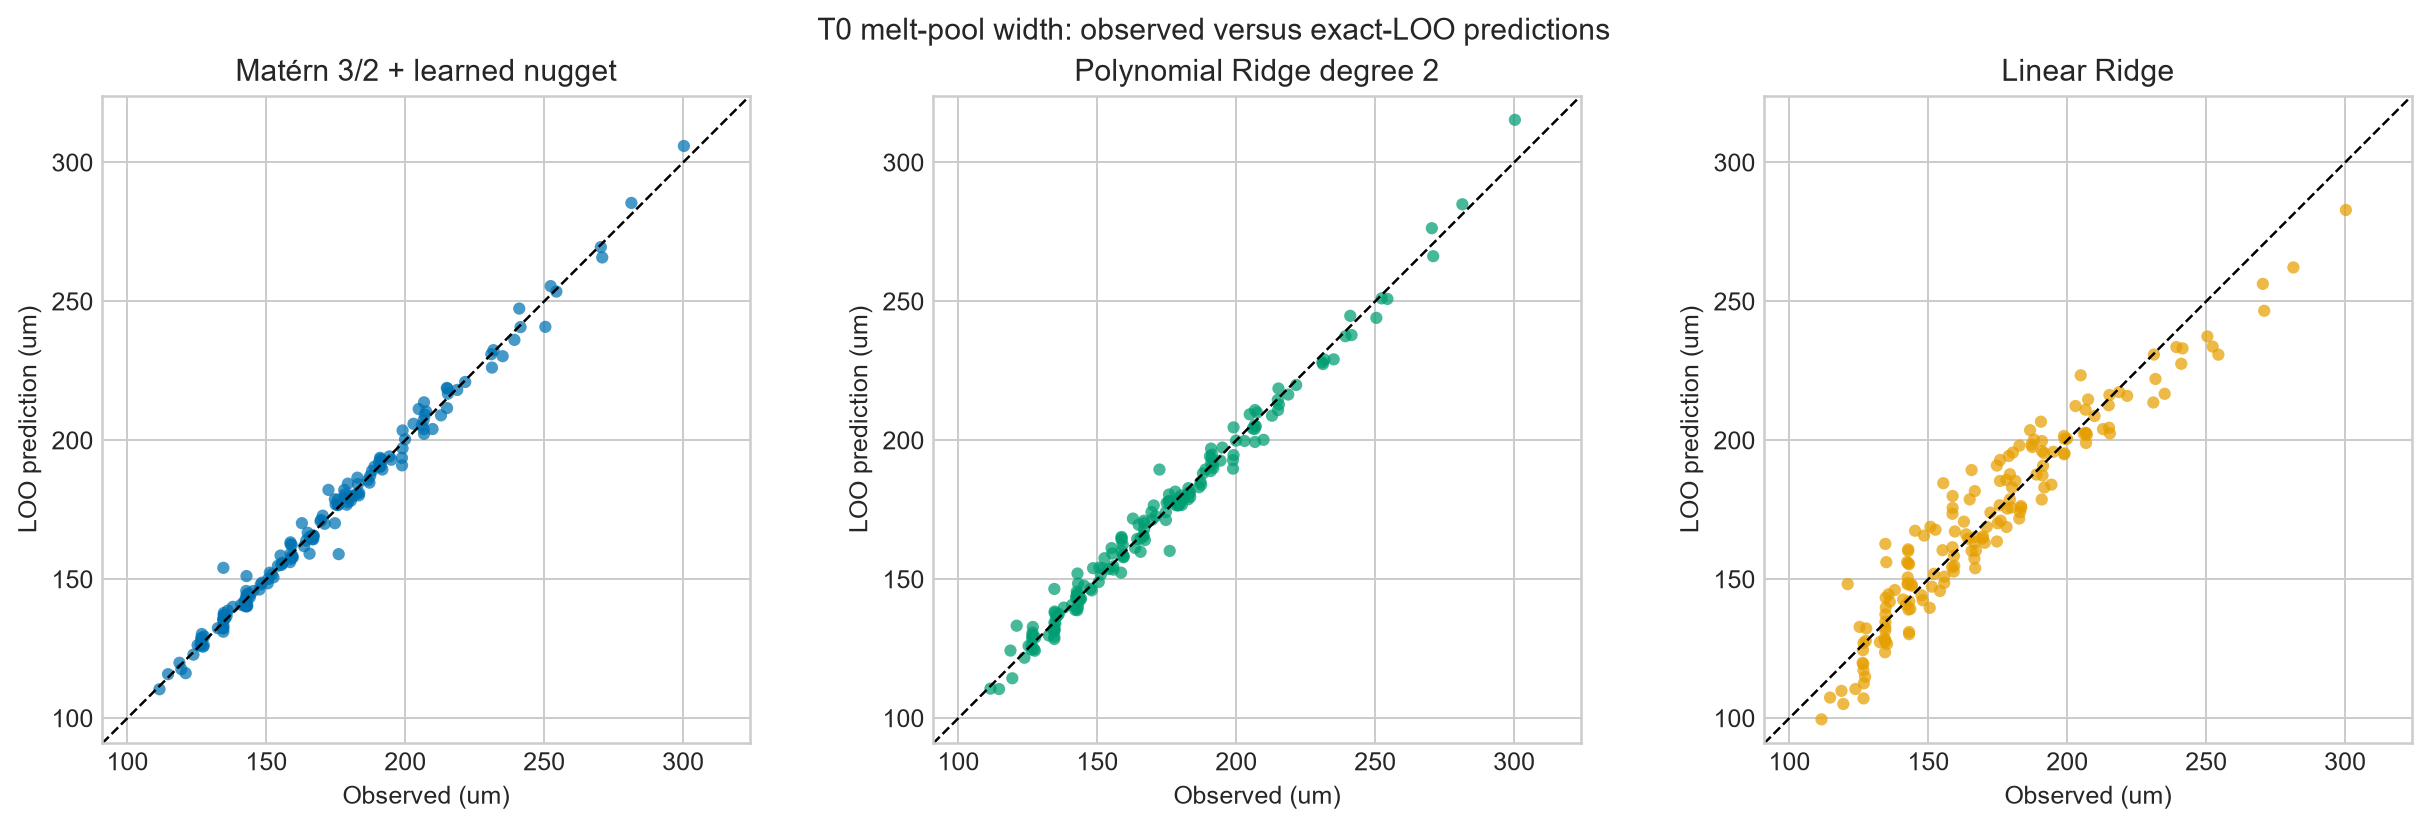

### depth

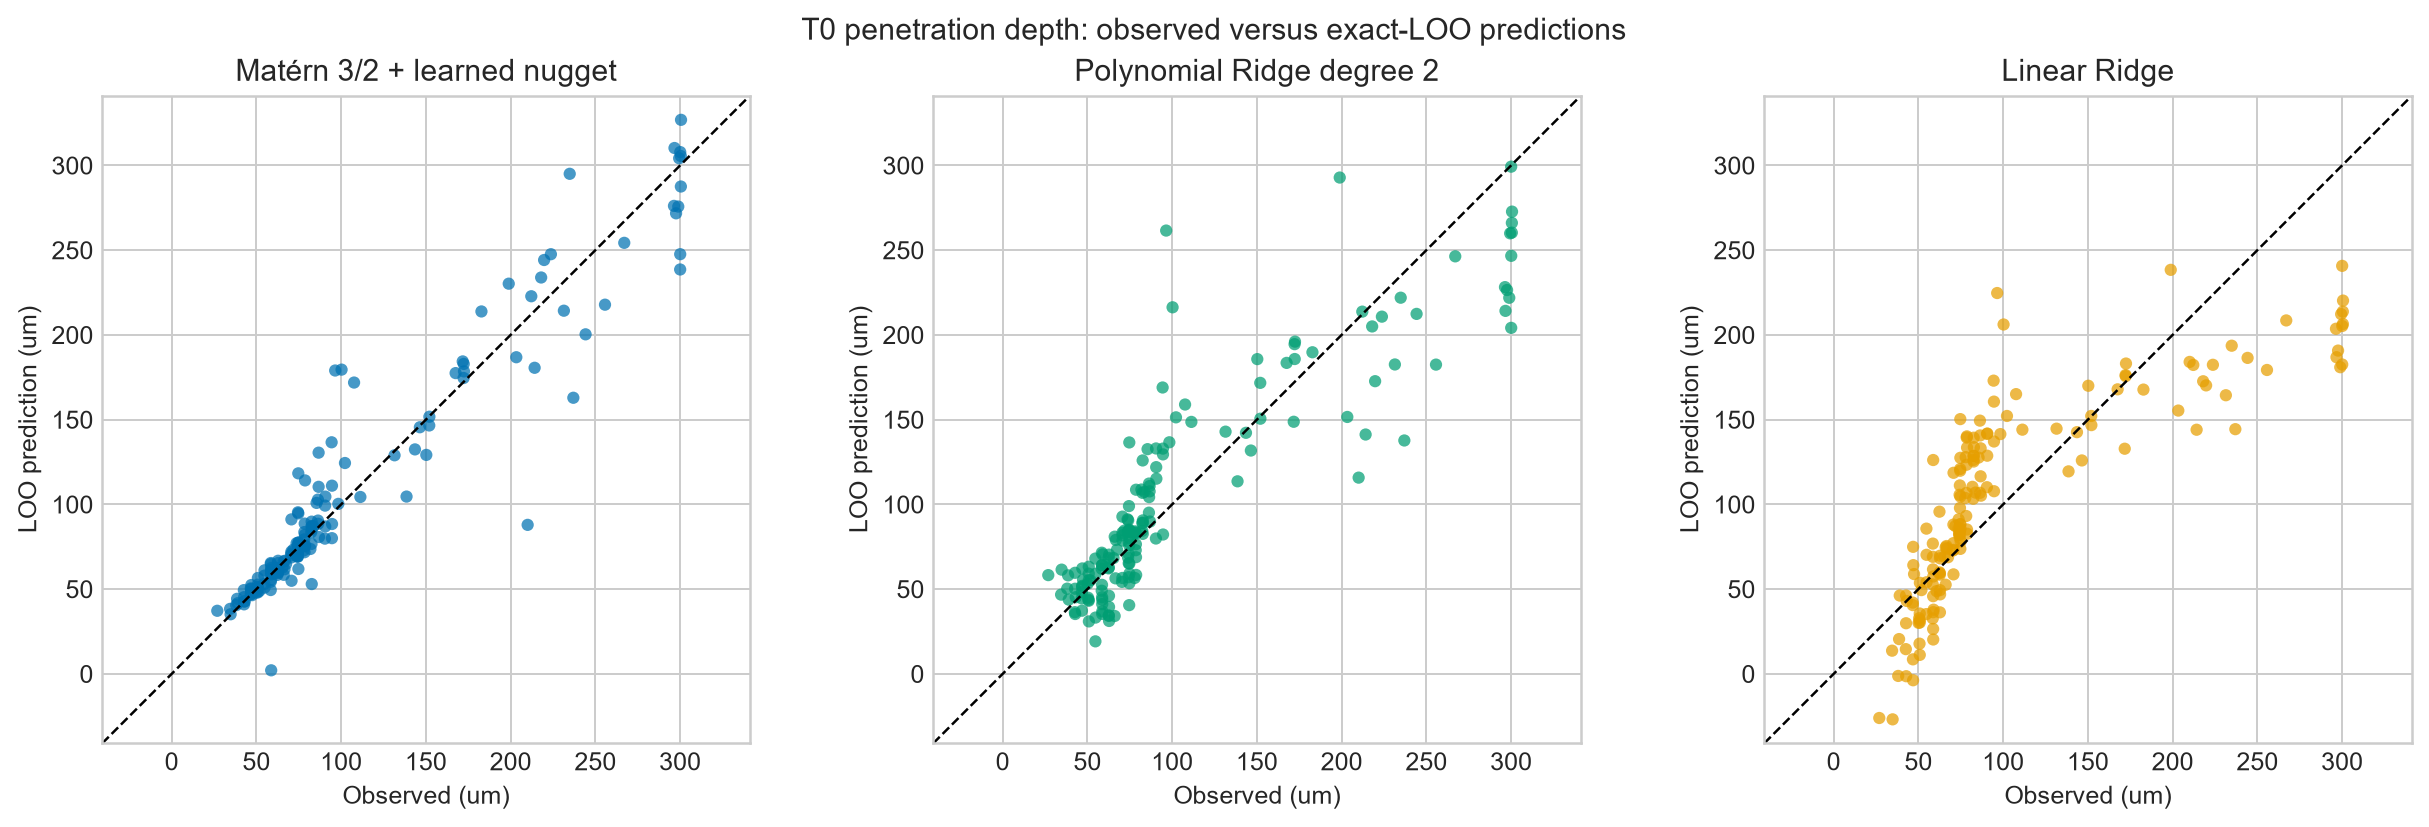

### total_height

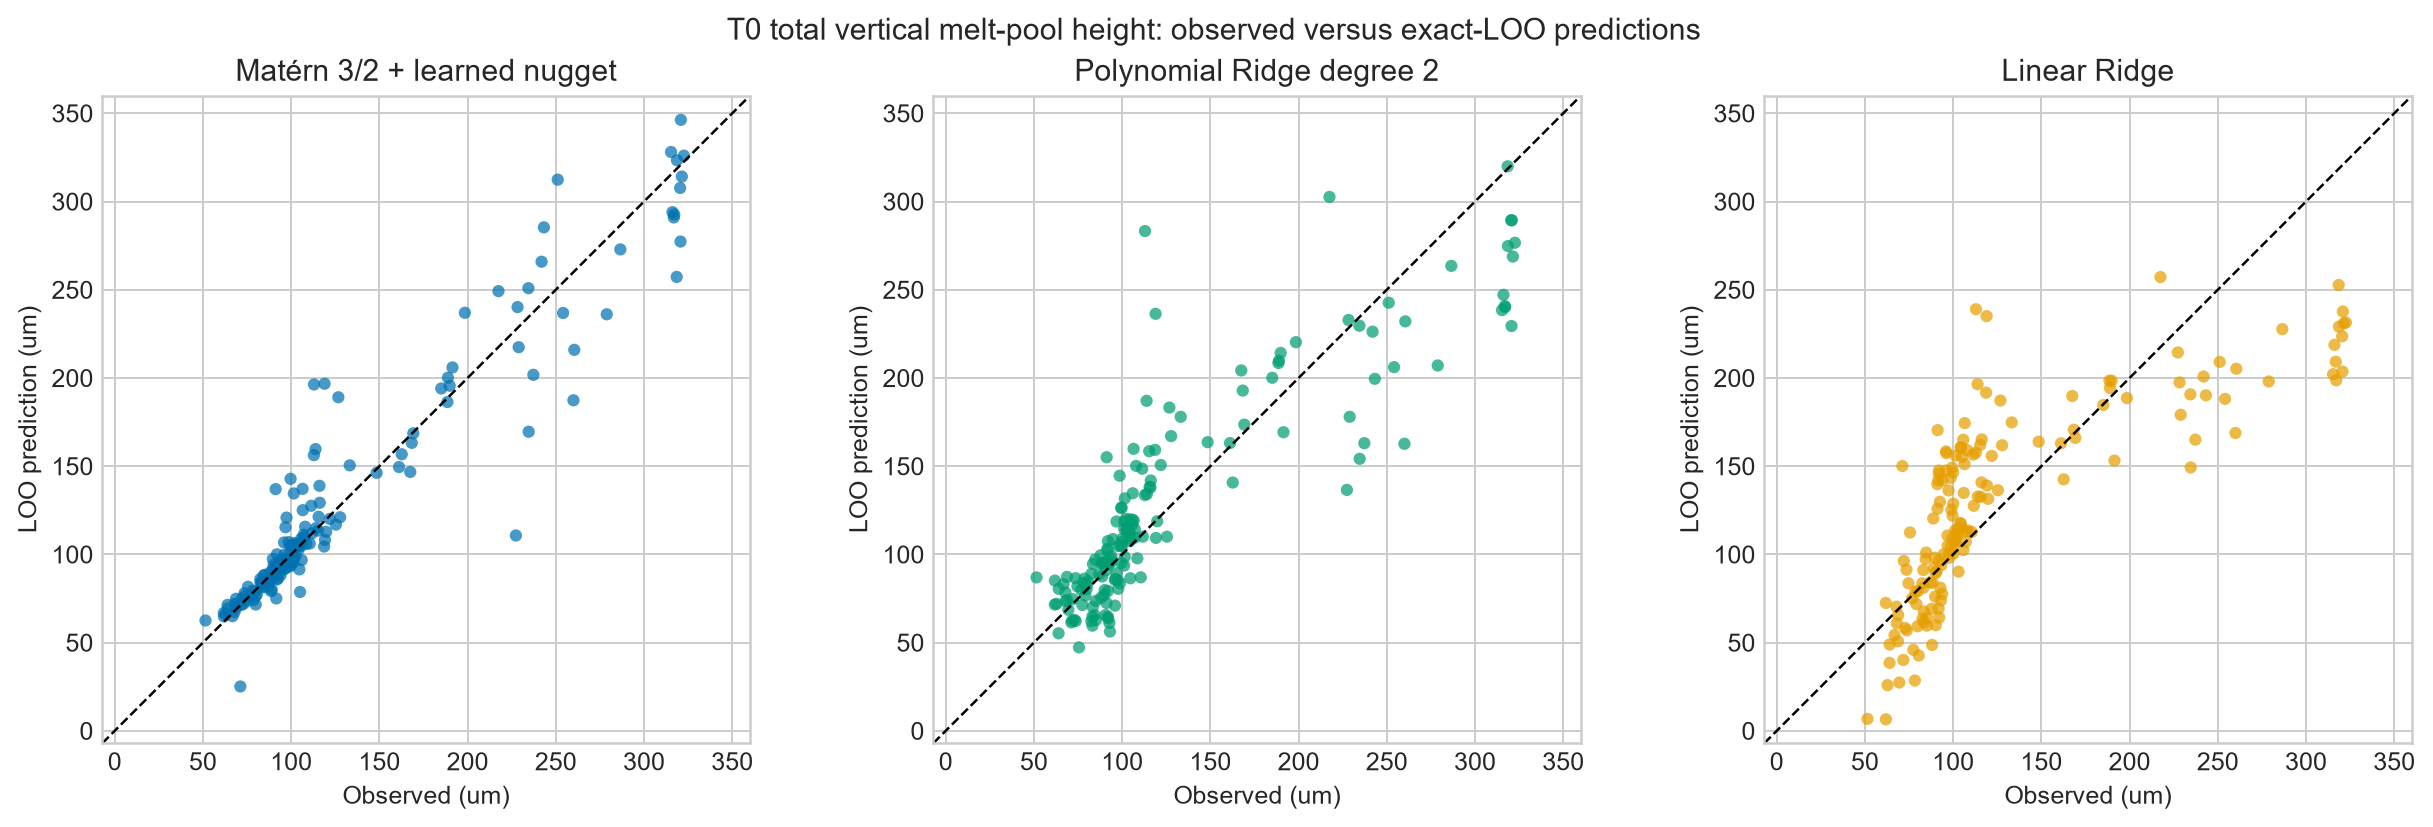

### kinetic_energy

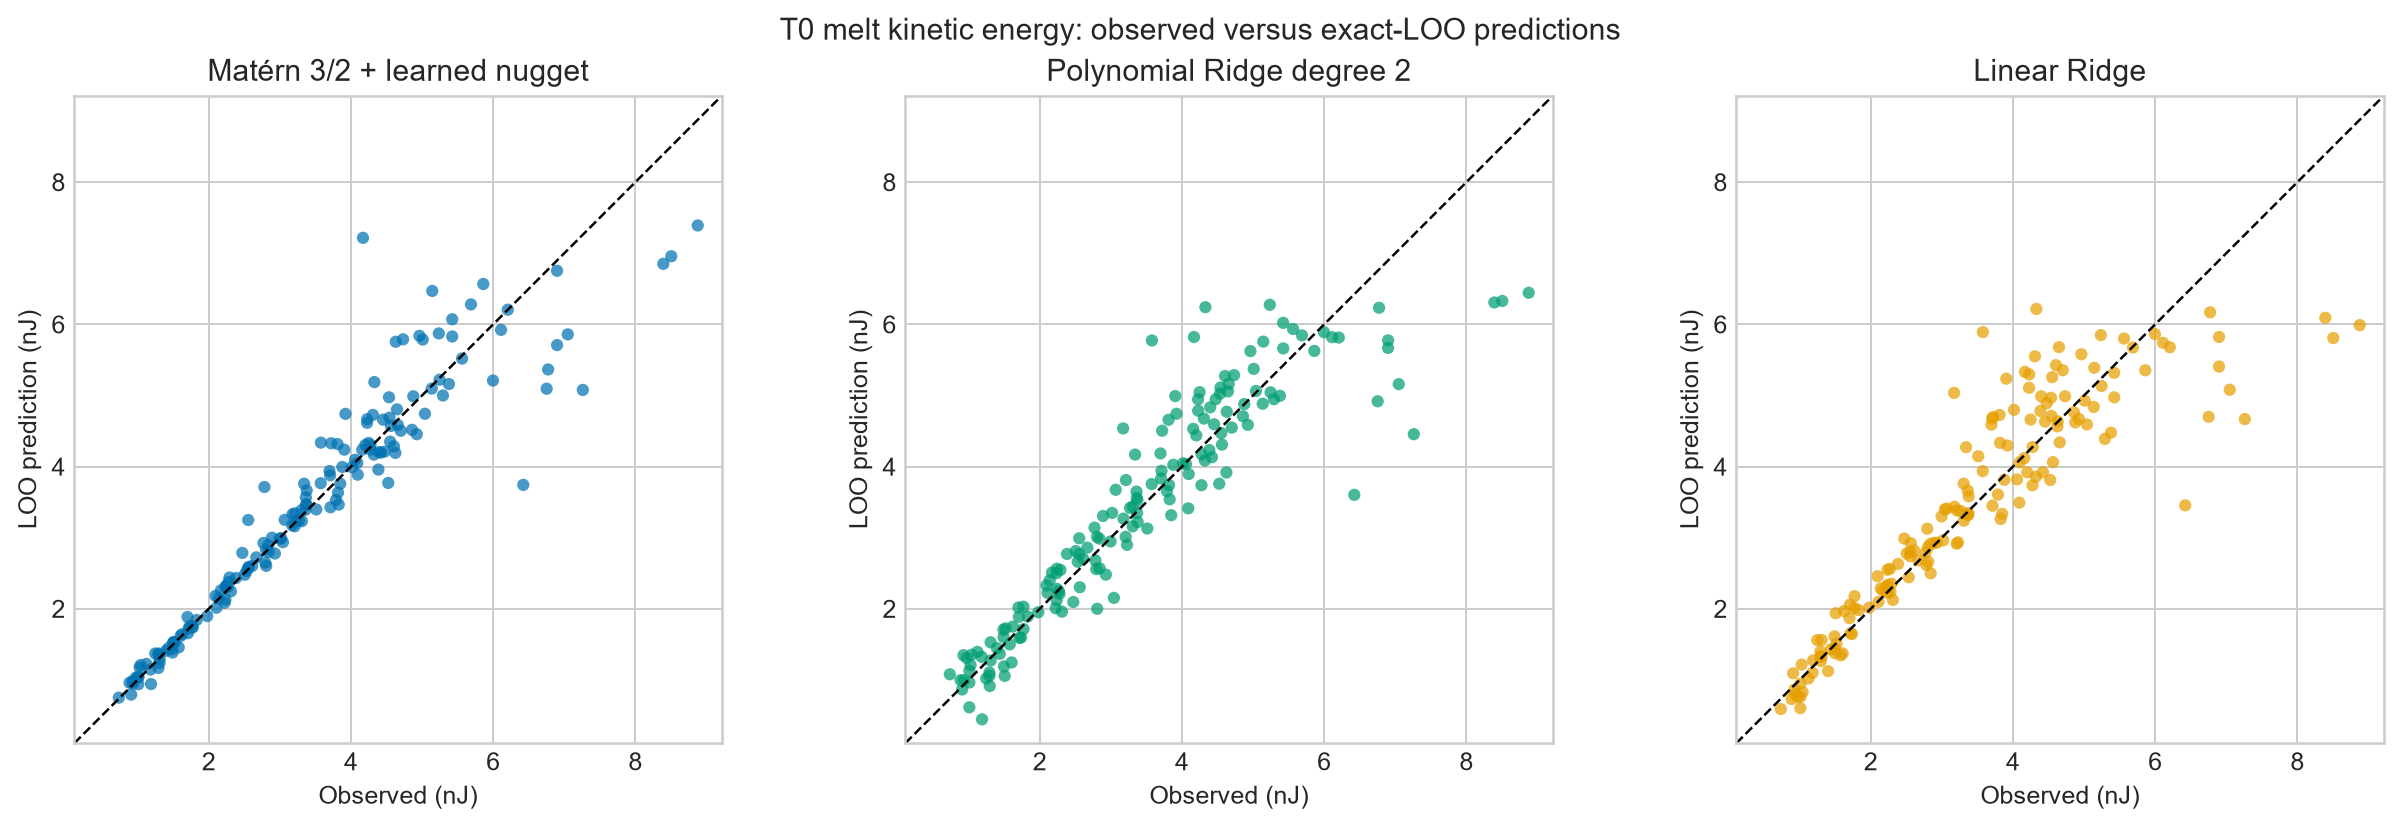

In [10]:
for target in ["width", "depth", "total_height", "kinetic_energy"]:
    filename = next(p.name for p in (OUT / "figures").glob(f"*_{target}_observed_vs_predicted.png"))
    display(Markdown(f"### {target}"))
    display(Image(filename=str(OUT / "figures" / filename), width=900))

**What did we observe?** All points are simulation-level out-of-sample predictions. Identity lines and shared axes expose both scale compression and major errors; no observation is removed because it hurts a model.

## 11. Residual and error-versus-scale diagnostics

**What are we doing?** Inspect residual distributions and absolute error versus observed response scale for each target.  
**Why?** Model rankings are incomplete without checking skew, heteroscedasticity, and influential cases.  
**What question does this answer?** Are errors centered, and do they grow systematically with target magnitude?  
**What would be suspicious?** A strongly shifted residual distribution, unexplained scale trend, or outlier deletion.

C:\Users\ozgur\AppData\Local\Temp\ipykernel_3000\2349729240.py:1: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  residuals = pd.read_csv(OUT / "residual_diagnostics.csv")


### width

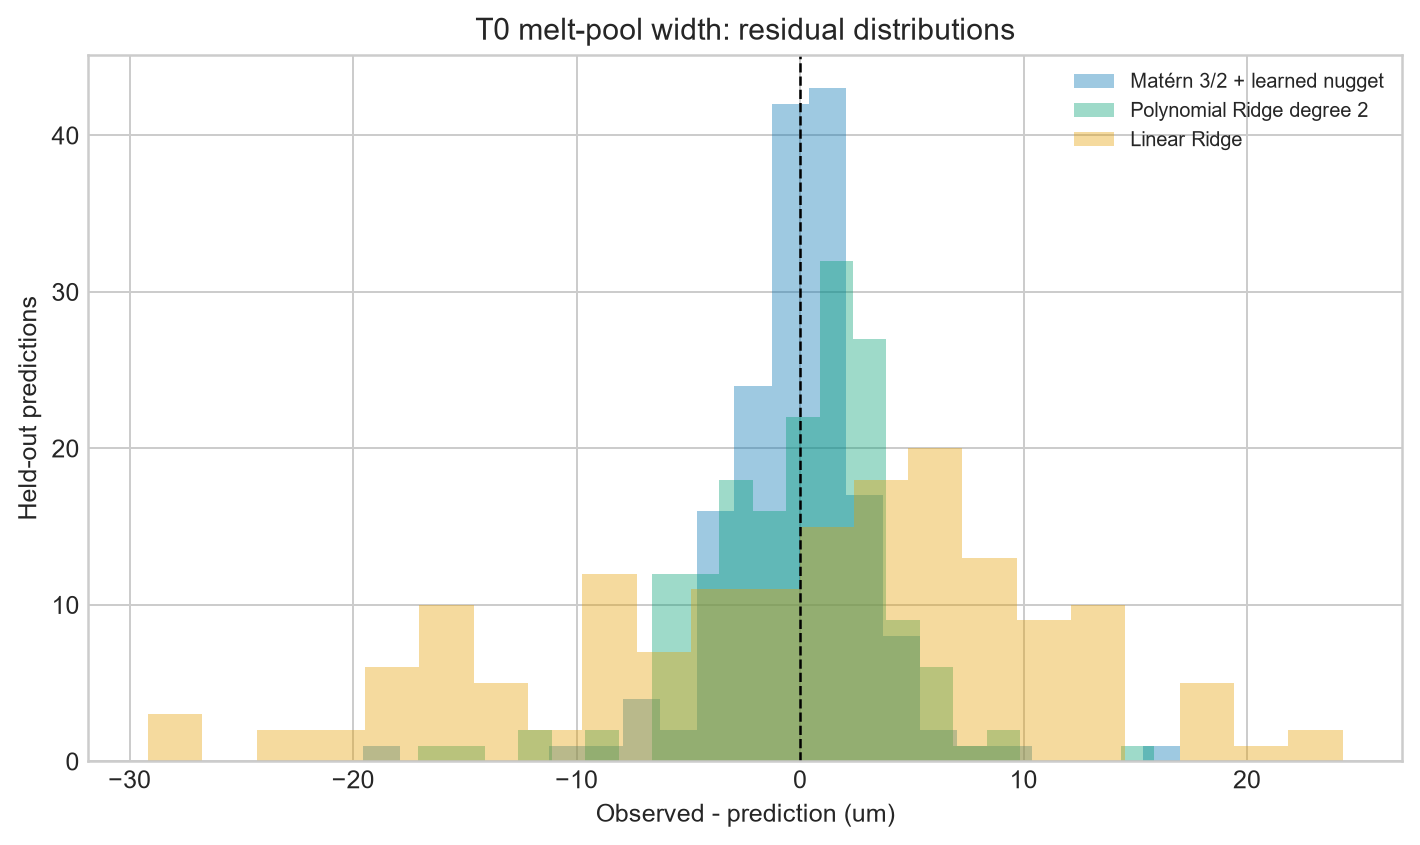

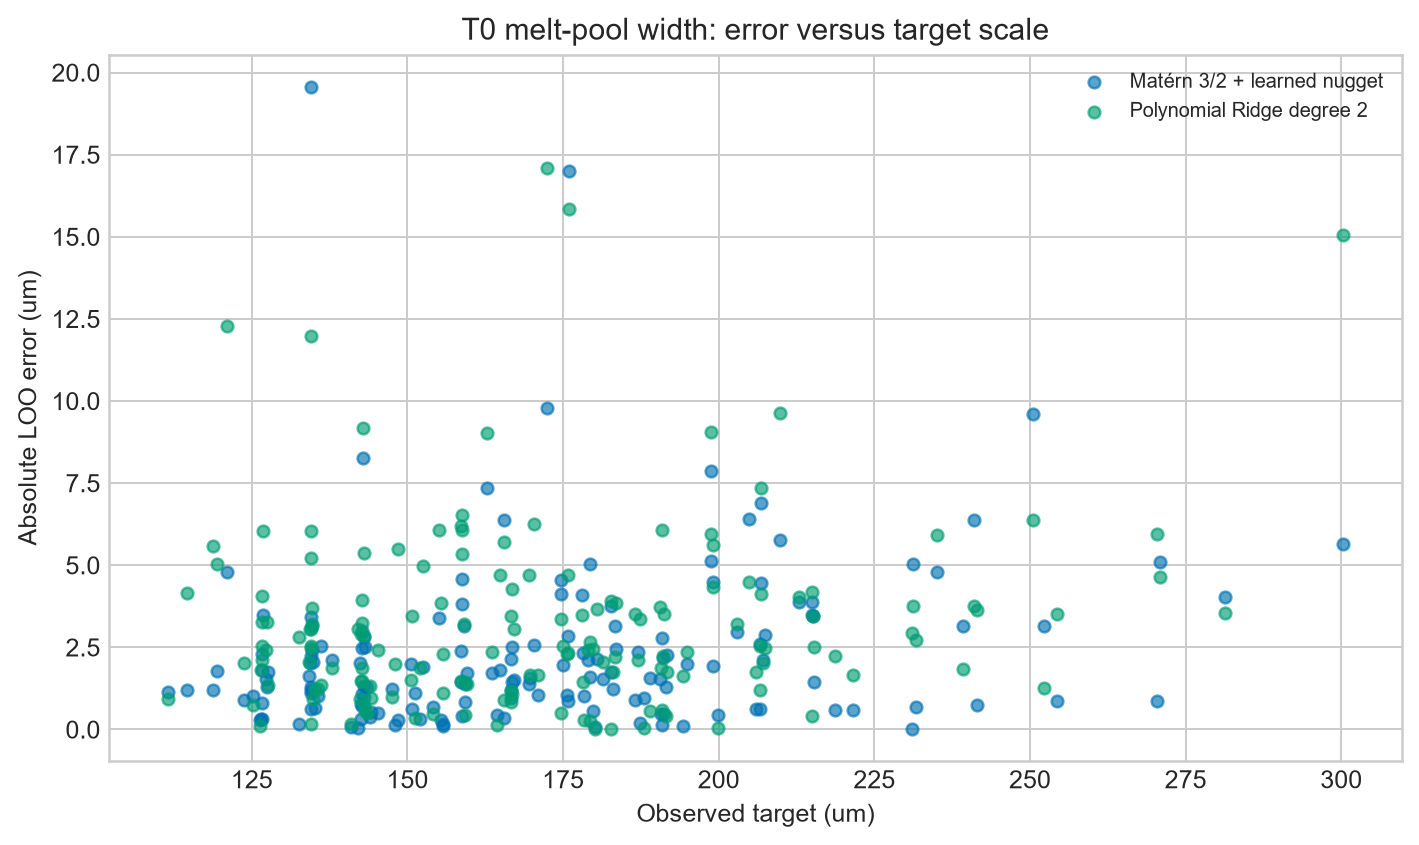

### depth

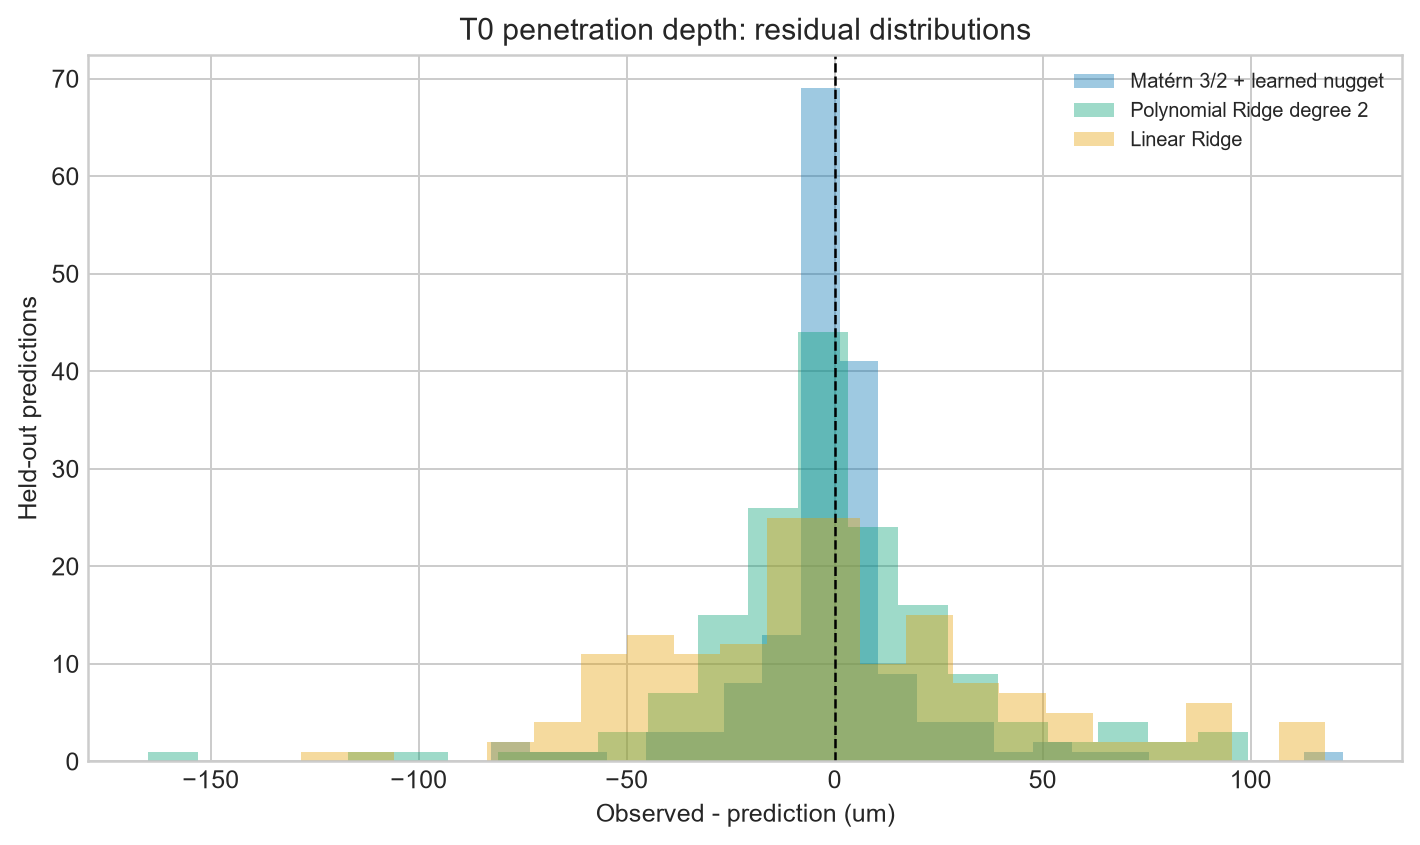

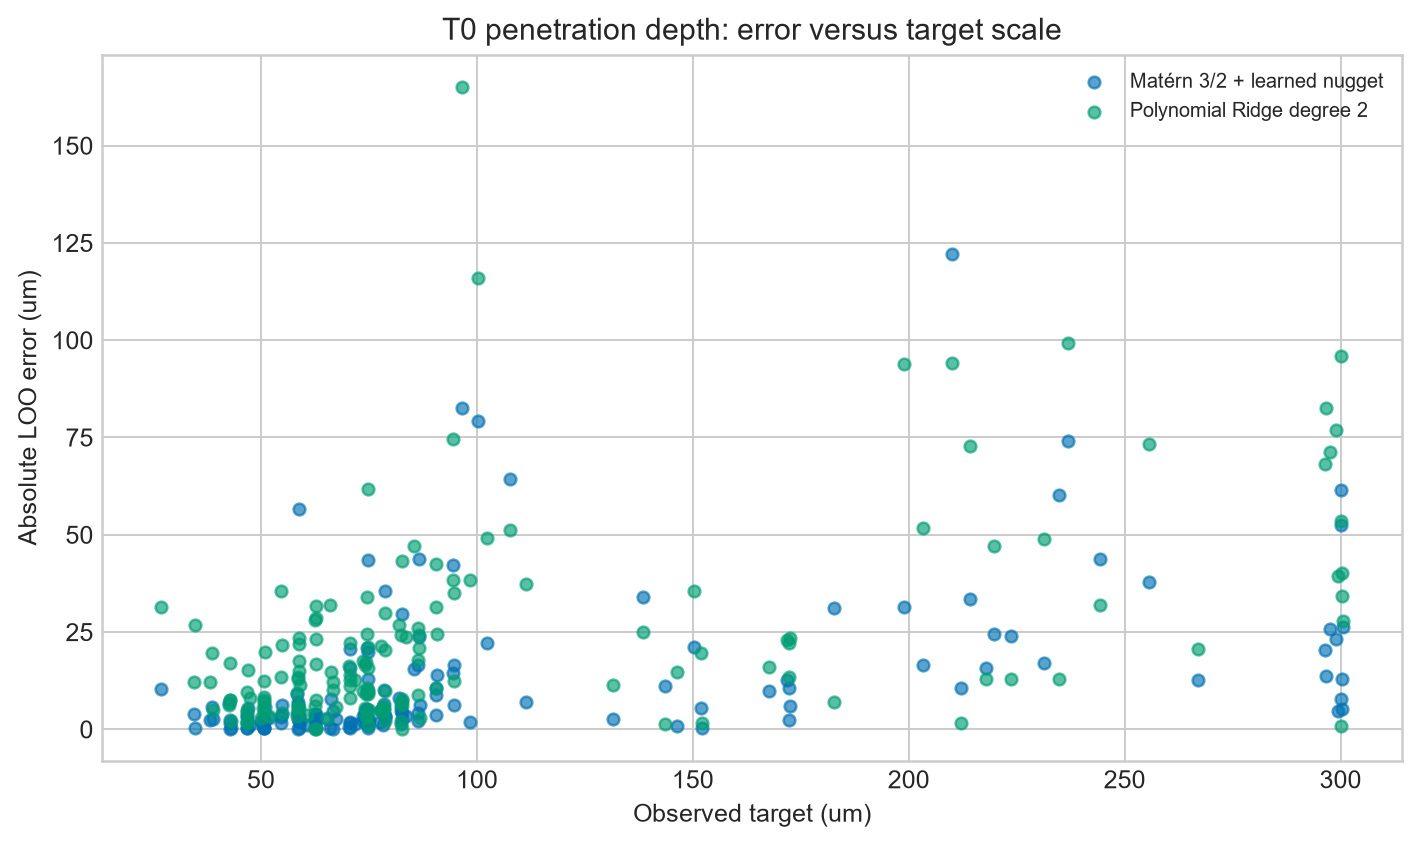

### total_height

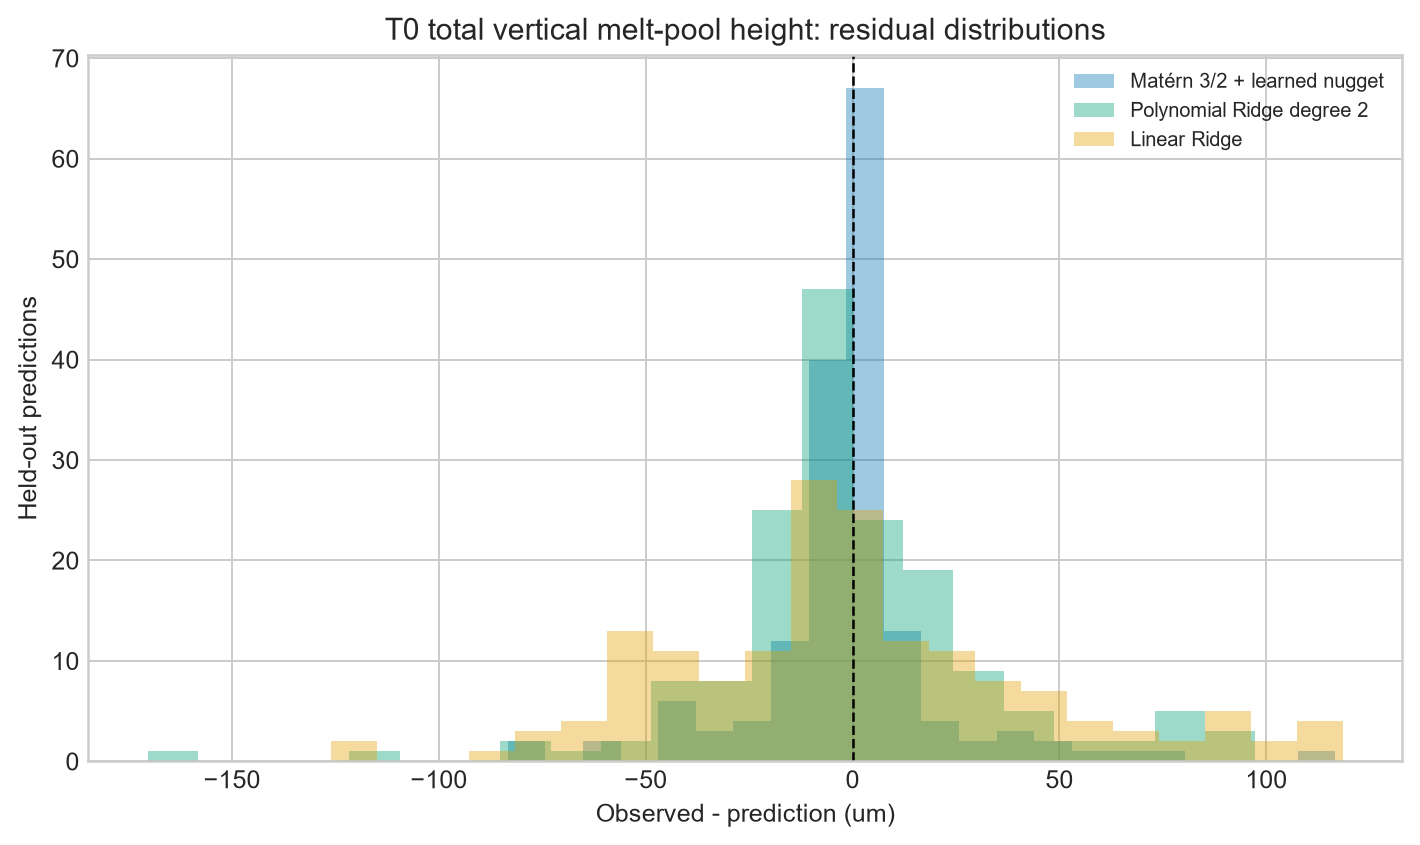

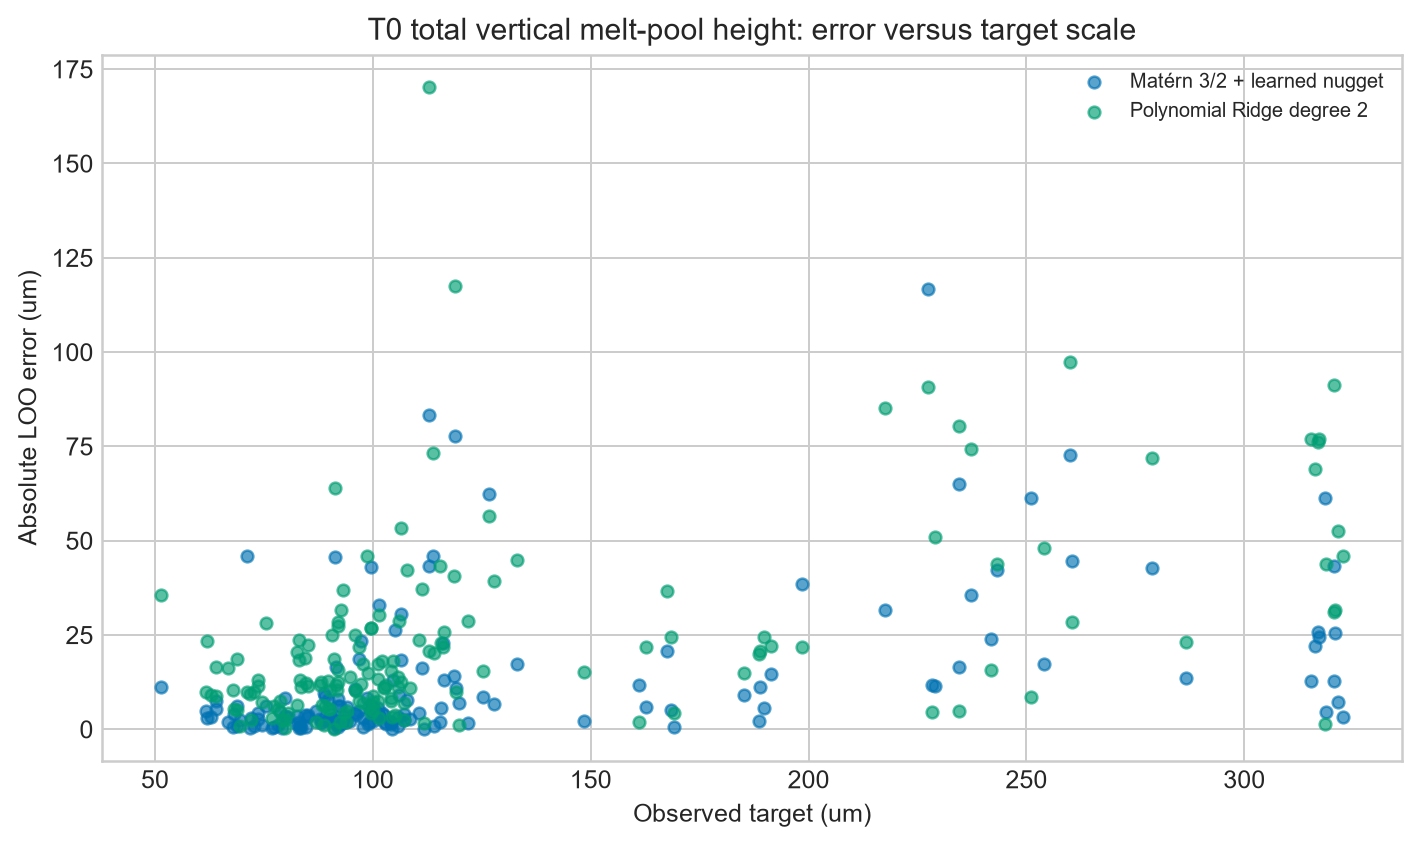

### kinetic_energy

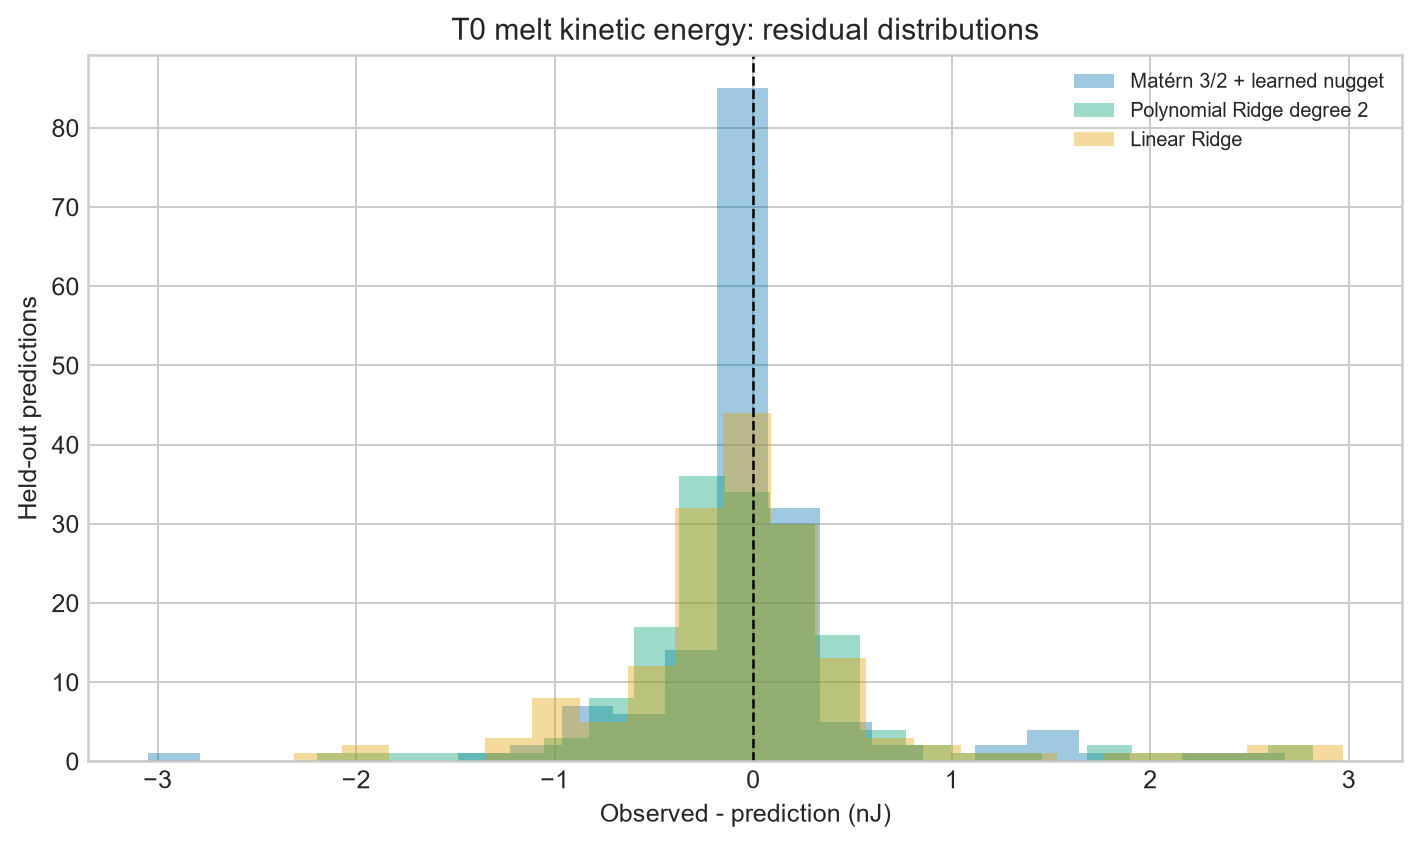

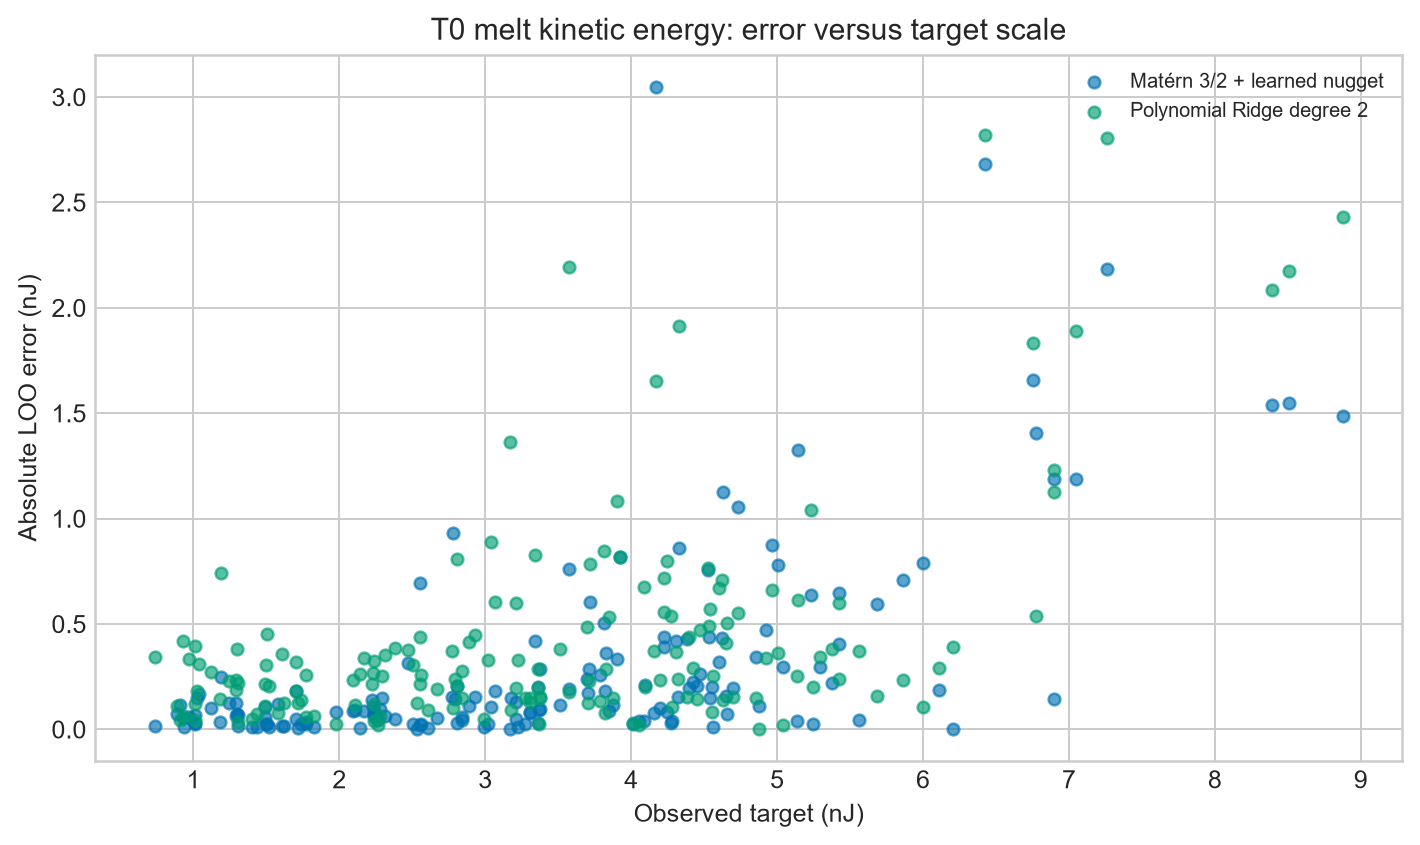

,target,model,experiment_name,observed_target_value,predicted_mean,absolute_error
117,depth,linear_ridge,P-360p567405001_VX-0p20359066256_LS-4p0817768449e-05_ST-337p353350673_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,96.473320,224.700435,128.227115
118,depth,linear_ridge,P-363p673556898_VX-0p448546579177_LS-4p04529881073e-05_ST-391p93586396_M-TI64_XI-0p0002_XF-0p0014_XL-0p001...,298.897500,180.939788,117.957712
116,depth,linear_ridge,P-358p08766286_VX-0p398145183006_LS-4p39068251559e-05_ST-301p093308231_M-TI64_XI-0p0002_XF-0p0014_XL-0p001...,300.047350,182.542299,117.505051
308,depth,matern32_heteroskedastic_alpha,P-408p574656479_VX-0p243547442248_LS-8p65536608509e-05_ST-318p028622224_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,210.032800,88.316008,121.716792
257,depth,matern32_heteroskedastic_alpha,P-293p648784497_VX-0p426690912013_LS-5p33940457289e-05_ST-351p677261216_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,236.995550,161.119707,75.875843
251,depth,matern32_heteroskedastic_alpha,P-277p972333632_VX-0p331196372511_LS-4p5620211888e-05_ST-324p411035281_M-TI64_XI-0p0002_XF-0p0014_XL-0p001...,107.620500,176.622902,69.002402
472,depth,matern32_learned_nugget,P-408p574656479_VX-0p243547442248_LS-8p65536608509e-05_ST-318p028622224_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,210.032800,87.917307,122.115493
445,depth,matern32_learned_nugget,P-360p567405001_VX-0p20359066256_LS-4p0817768449e-05_ST-337p353350673_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012...,96.473320,178.988440,82.515120
460,depth,matern32_learned_nugget,P-379p421209359_VX-0p229921993373_LS-5p57538994548e-05_ST-334p989783011_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,100.240900,179.511955,79.271055
636,depth,matern32_no_nugget,P-408p574656479_VX-0p243547442248_LS-8p65536608509e-05_ST-318p028622224_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,210.032800,88.466648,121.566152


In [11]:
residuals = pd.read_csv(OUT / "residual_diagnostics.csv")
for target in ["width", "depth", "total_height", "kinetic_energy"]:
    display(Markdown(f"### {target}"))
    residual_file = next(p for p in (OUT / "figures").glob(f"*_{target}_residual_distribution.png"))
    scale_file = next(p for p in (OUT / "figures").glob(f"*_{target}_error_vs_observed_scale.png"))
    display(Image(filename=str(residual_file), width=760))
    display(Image(filename=str(scale_file), width=760))
display(residuals[residuals["major_outlier_flag_top3"].astype(bool)]
    [["target", "model", "experiment_name", "observed_target_value", "predicted_mean", "absolute_error"]]
    .sort_values(["target", "model", "absolute_error"], ascending=[True, True, False]).head(40))

**What did we observe?** Major errors are flagged conservatively for inspection, not excluded. Their experiment identifiers remain linked to every fold-level prediction and the complete audit population.

## 12. Predictive interval and calibration diagnostics

**What are we doing?** Compare held-out 95% coverage, NLPD, interval widths, and standardized residual behavior for deployable GP intervals and retrospective Method C intervals.  
**Why?** A low point RMSE does not guarantee calibrated predictive uncertainty.  
**What question does this answer?** Which probabilistic model is best calibrated, and is the shared-nugget conclusion supported beyond point error?  
**What would be suspicious?** Intervals with reversed bounds, a mean outside its own interval, treating Method C as deployable, or claiming exact 95% coverage is guaranteed.

,target,model,model_label,n,coverage_95,coverage_error_from_0_95,median_interval_width,standardized_residual_mean,standardized_residual_std,standardized_residual_q025,standardized_residual_q975,interval_definition,retrospective_oracle,dataset_revision
5,depth,rbf_learned_nugget,RBF + learned nugget,164,0.932927,0.017073,68.494739,-0.027721,1.112132,-2.794353,2.508241,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec
1,depth,matern32_learned_nugget,Matérn 3/2 + learned nugget,164,0.920732,0.029268,70.772790,-0.022240,1.061575,-2.439901,2.621030,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec
3,depth,matern52_learned_nugget,Matérn 5/2 + learned nugget,164,0.920732,0.029268,68.376173,-0.021616,1.083436,-2.587032,2.602901,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec
0,depth,matern32_heteroskedastic_alpha,Matérn 3/2 + heteroskedastic alpha,164,0.914634,0.035366,70.753101,-0.031930,1.065650,-2.380068,2.527920,retrospective oracle: latent variance plus held-out target-summary variance,True,d69dac5bda8b622bc0de316b112815c6056c06ec
2,depth,matern32_no_nugget,"Matérn 3/2, numerical jitter",164,0.914634,0.035366,71.100995,-0.033015,1.063558,-2.380238,2.525608,latent predictive variance; numerical jitter excluded,False,d69dac5bda8b622bc0de316b112815c6056c06ec
4,depth,matern52_no_nugget,"Matérn 5/2, numerical jitter",164,0.908537,0.041463,72.325923,-0.043497,1.122457,-2.504459,2.364084,latent predictive variance; numerical jitter excluded,False,d69dac5bda8b622bc0de316b112815c6056c06ec
6,depth,rbf_no_nugget,"RBF, numerical jitter",164,0.902439,0.047561,80.141529,-0.060754,1.181552,-2.767671,2.729626,latent predictive variance; numerical jitter excluded,False,d69dac5bda8b622bc0de316b112815c6056c06ec
8,kinetic_energy,matern32_learned_nugget,Matérn 3/2 + learned nugget,164,0.932927,0.017073,2.040523,0.003801,1.076604,-1.882774,2.879113,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec
12,kinetic_energy,rbf_learned_nugget,RBF + learned nugget,164,0.932927,0.017073,2.070621,0.006502,1.074848,-1.736522,3.009995,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec
10,kinetic_energy,matern52_learned_nugget,Matérn 5/2 + learned nugget,164,0.926829,0.023171,2.061001,0.004281,1.075901,-1.714625,2.950366,total predictive variance including learned WhiteKernel nugget,False,d69dac5bda8b622bc0de316b112815c6056c06ec


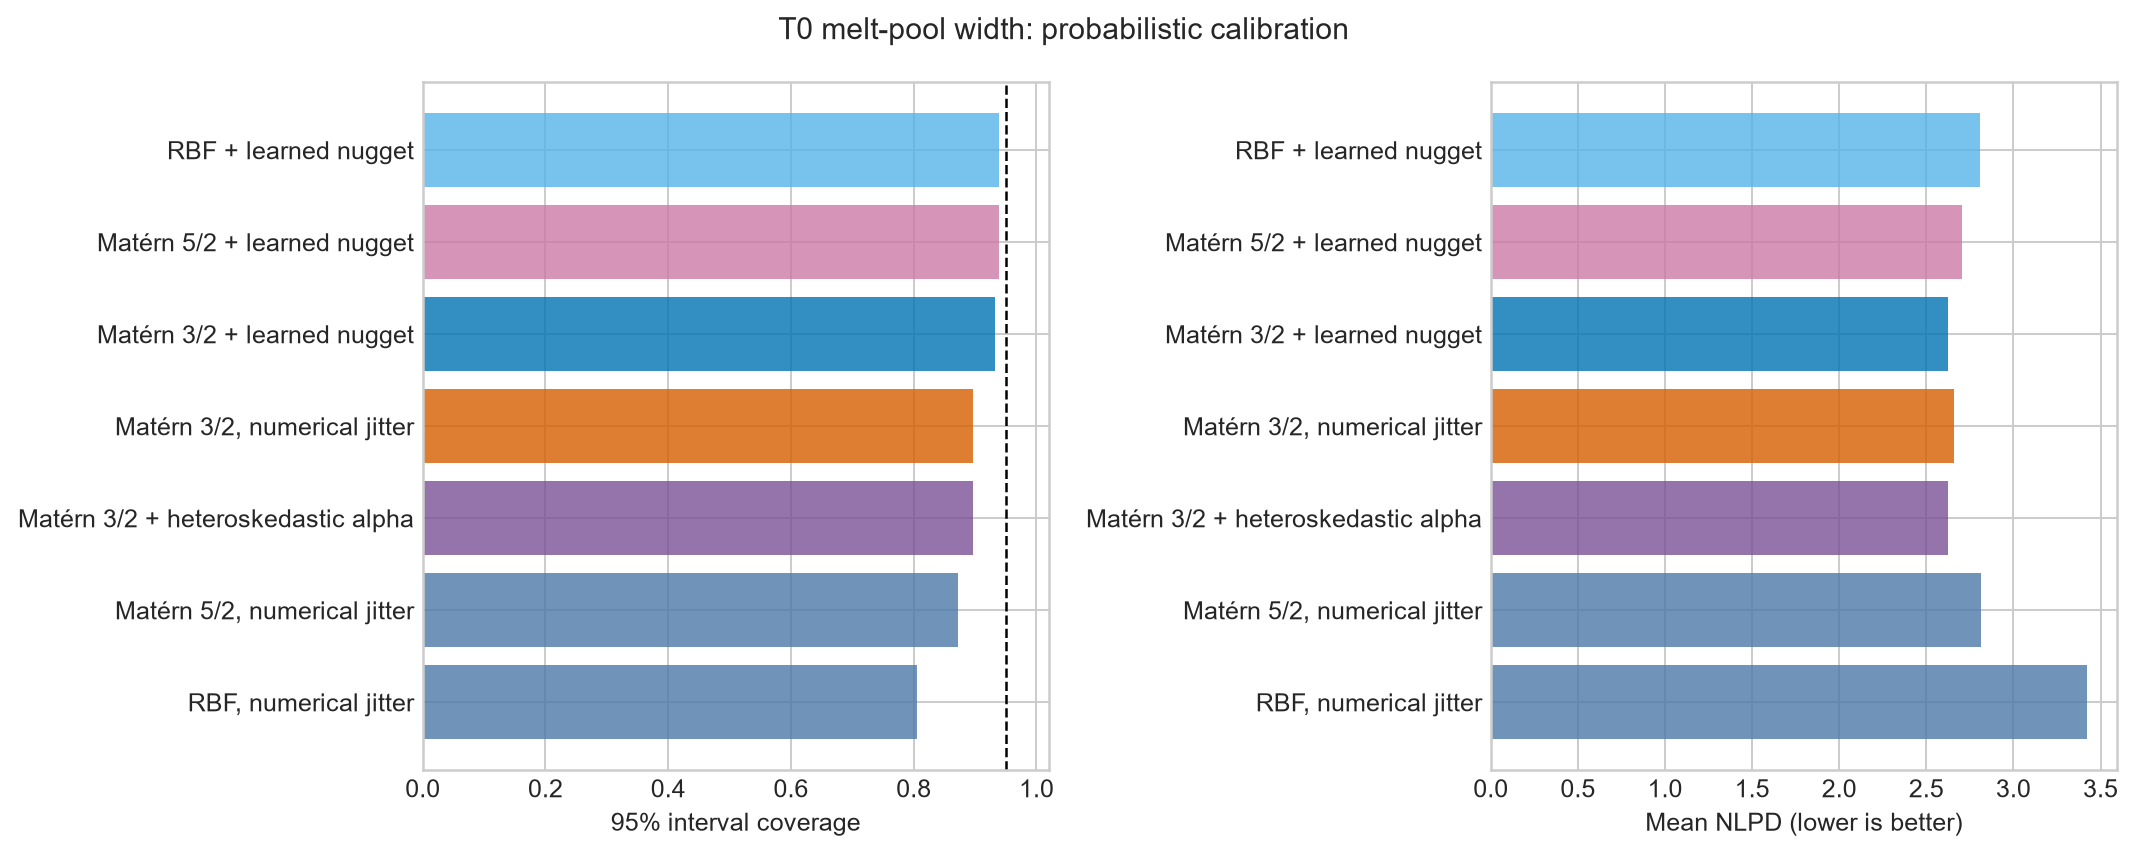

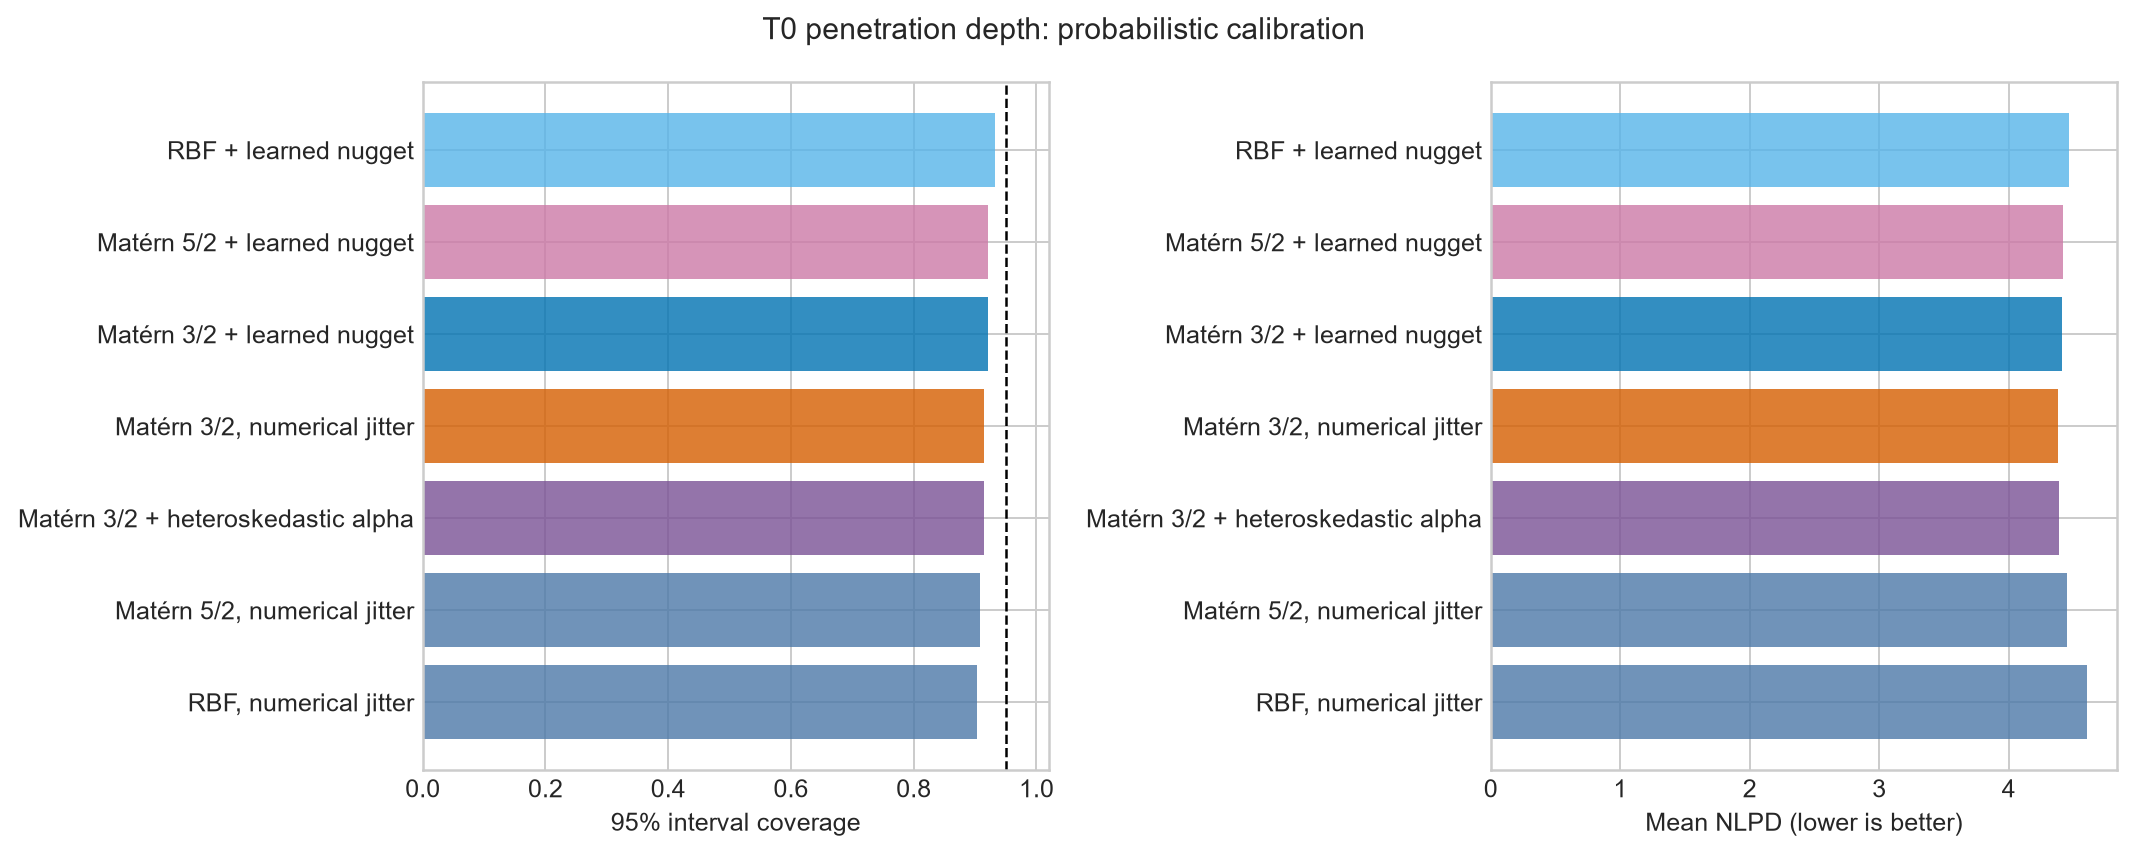

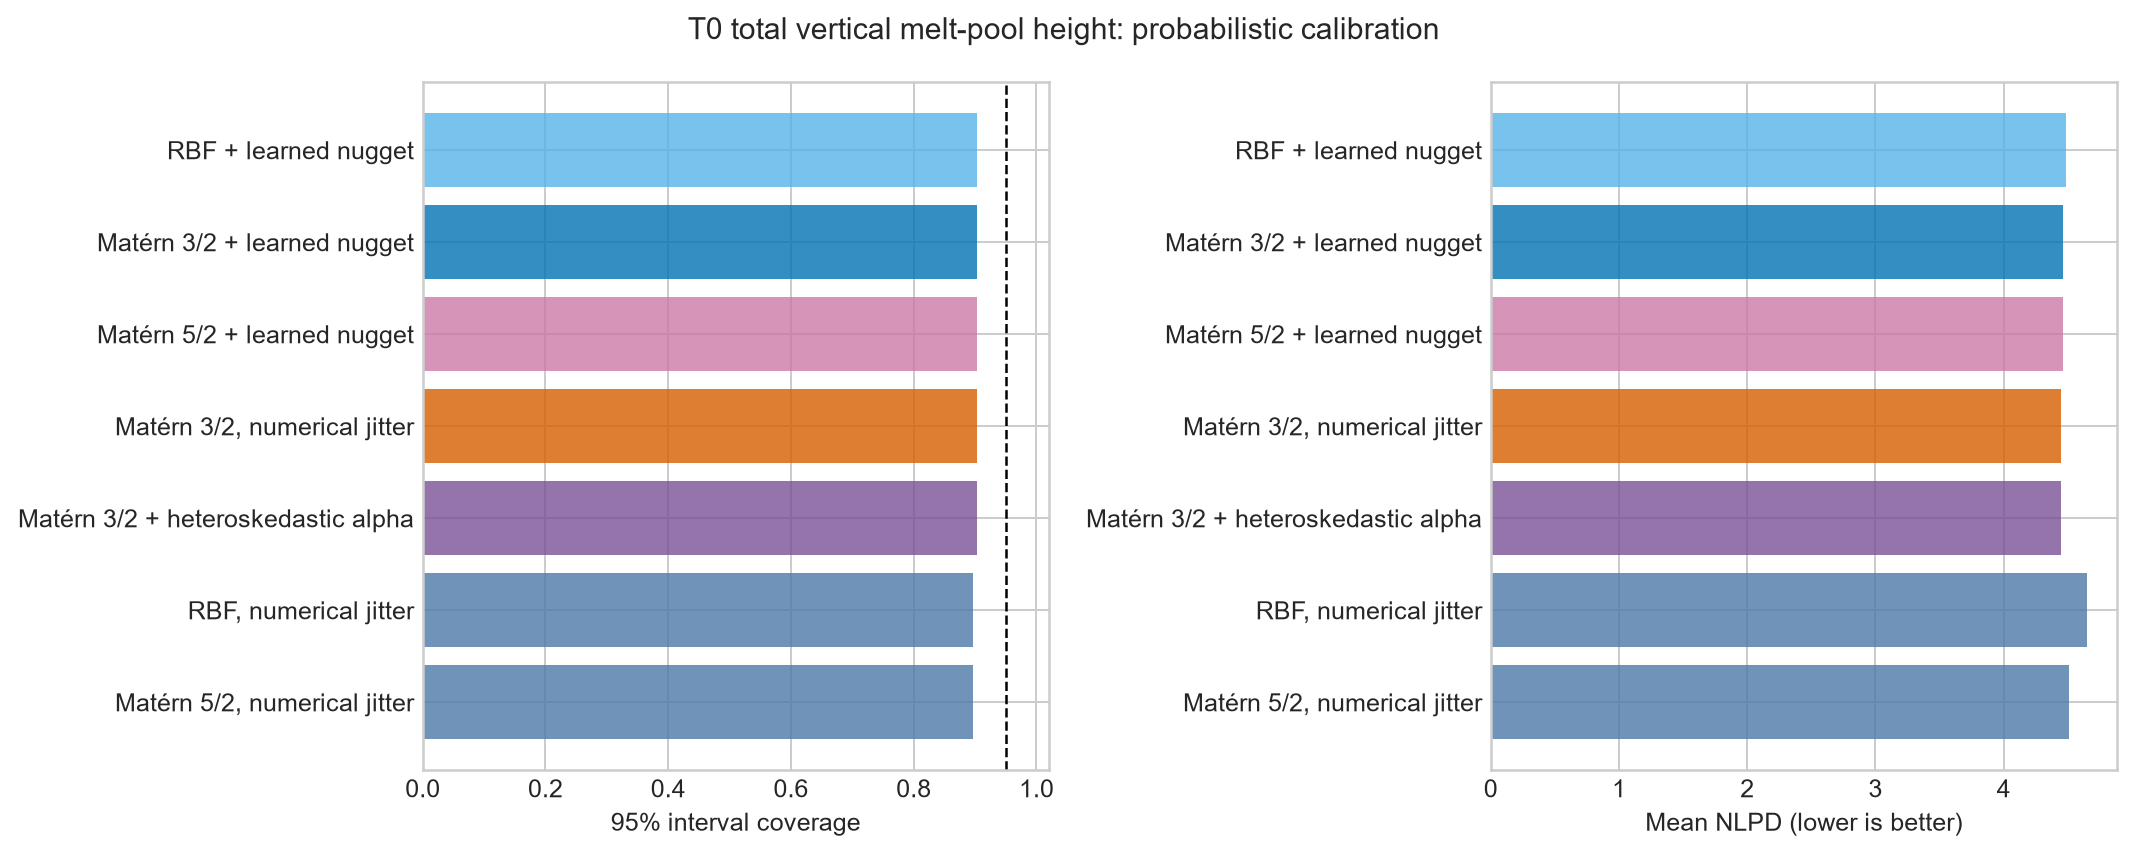

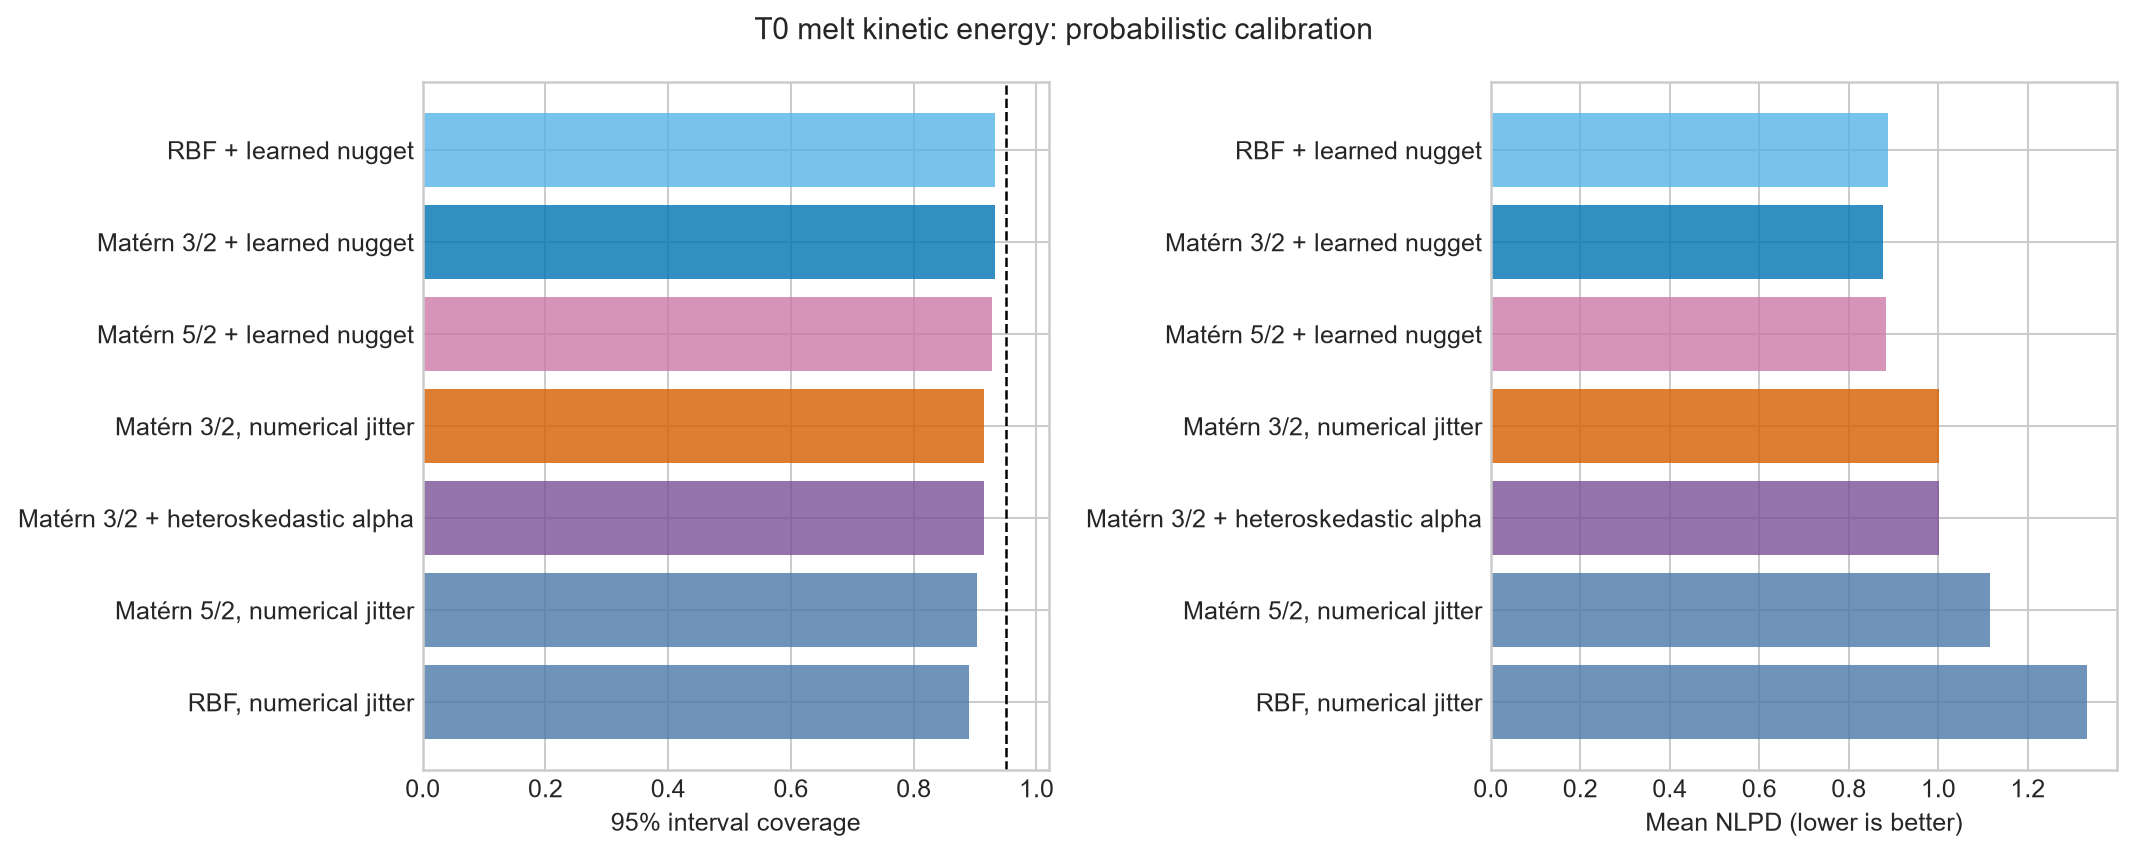

In [12]:
intervals = pd.read_csv(OUT / "predictive_interval_diagnostics.csv")
interval_rows = pred[pred["predictive_interval_lower"].notna()]
assert (interval_rows["predictive_interval_lower"] <= interval_rows["predicted_mean"]).all()
assert (interval_rows["predicted_mean"] <= interval_rows["predictive_interval_upper"]).all()
display(intervals.sort_values(["target", "coverage_error_from_0_95", "model"]))
for target in ["width", "depth", "total_height", "kinetic_energy"]:
    filename = next(p for p in (OUT / "figures").glob(f"*_{target}_predictive_interval_calibration.png"))
    display(Image(filename=str(filename), width=860))

**What did we observe?** Calibration is assessed independently from point ranking. Method C remains labeled retrospective/oracle; learned-nugget gains are predictive-model evidence, not proof that the simulator or physical measurements are noisy.

## 13. Week 6 versus new-data stability comparison

**What are we doing?** Place saved Week 6 old-design results beside the independent new-data results without refitting or pooling the old population.  
**Why?** Replication concerns ranking, relative error, kernel/noise preference, and calibration—not absolute native-unit errors alone across shifted target distributions.  
**What question does this answer?** Did the new sampled parameter domain materially change model difficulty or the qualitative conclusions?  
**What would be suspicious?** A pooled primary model, a claim based only on absolute RMSE, or a causal claim that the physics became more complex.

,target,target_label,target_unit,week6_n,new_data_n,week6_selected_point_model,new_data_selected_point_model,week6_best_learned_gp_kernel,week6_protocol_selected_gp,new_data_best_learned_gp_kernel,new_data_protocol_selected_gp,week6_learned_nugget_useful,new_data_learned_nugget_useful,week6_MAE,new_data_MAE,week6_relative_MAE_pct,new_data_relative_MAE_pct,week6_RMSE,new_data_RMSE,week6_relative_RMSE_pct,new_data_relative_RMSE_pct,week6_R2,new_data_R2,week6_target_median_scale,new_data_target_median_scale,week6_gp_minus_polynomial_RMSE,new_data_gp_minus_polynomial_RMSE,relative_RMSE_ratio_new_over_week6,model_difficulty_observation,point_model_same,protocol_gp_same,dataset_populations_pooled,new_dataset_revision
0,depth,T0 penetration depth,um,230,164,matern32_learned_nugget,matern32_learned_nugget,matern52_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,True,False,1.802271,11.937466,3.293484,15.971677,2.728943,21.808185,4.986892,29.178159,0.968873,0.910306,54.722320,74.741470,-1.159565,-11.795635,5.850971,higher relative out-of-sample error in the new sampled domain,True,True,False,d69dac5bda8b622bc0de316b112815c6056c06ec
1,kinetic_energy,T0 melt kinetic energy,nJ,241,164,linear_ridge,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,True,True,0.115385,0.302242,7.543145,9.022208,0.187518,0.563873,12.258805,16.832141,0.940969,0.889965,1.529661,3.349977,-0.005908,-0.114844,1.373065,higher relative out-of-sample error in the new sampled domain,False,True,False,d69dac5bda8b622bc0de316b112815c6056c06ec
2,total_height,T0 total vertical melt-pool height,um,241,164,polynomial_ridge_degree2,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern52_learned_nugget,matern32_learned_nugget,True,False,5.293909,12.609078,6.608615,12.530293,8.522625,22.400591,10.639160,22.260626,0.782161,0.900243,80.106185,100.628758,-0.924417,-11.841522,2.092329,higher relative out-of-sample error in the new sampled domain,False,True,False,d69dac5bda8b622bc0de316b112815c6056c06ec
3,width,T0 melt-pool width,um,241,164,polynomial_ridge_degree2,polynomial_ridge_degree2,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,matern32_learned_nugget,True,True,3.387664,3.240673,2.130536,1.944519,6.725322,4.299549,4.229623,2.579883,0.967729,0.986075,159.005220,166.656785,-0.028967,-0.794845,0.609956,lower relative out-of-sample error in the new sampled domain,True,True,False,d69dac5bda8b622bc0de316b112815c6056c06ec


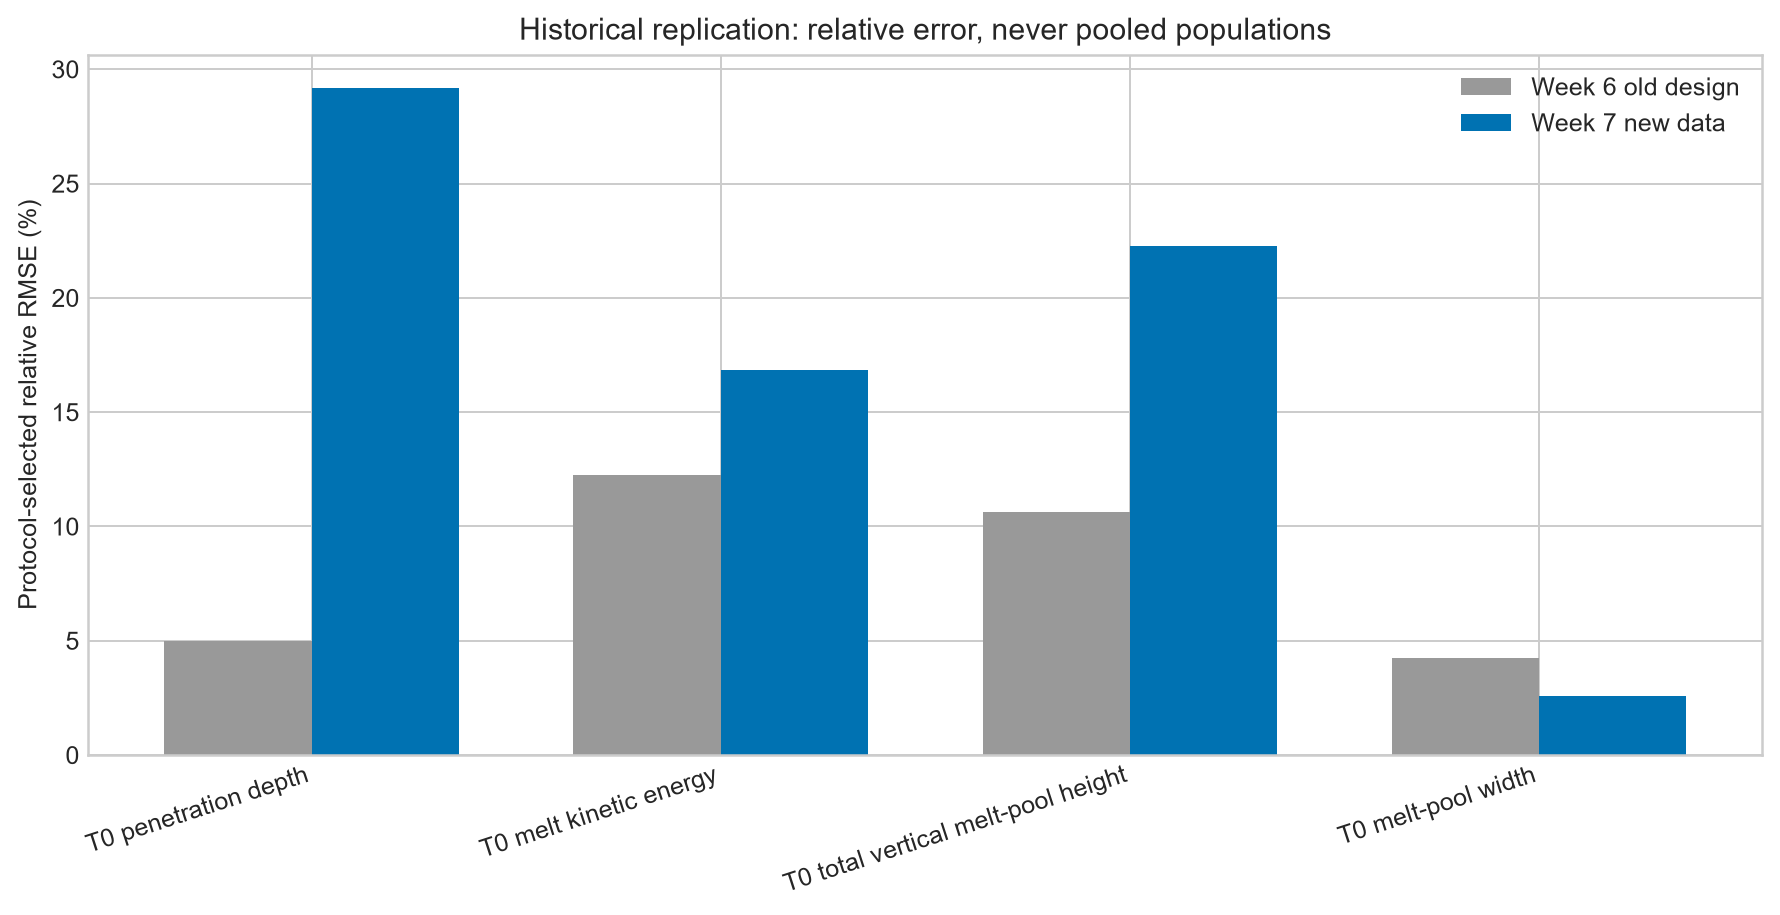

In [13]:
historical = pd.read_csv(OUT / "week6_vs_new_data_comparison.csv")
display(historical)
display(Image(filename=str(next((OUT / "figures").glob("*_week6_vs_new_data_relative_rmse.png"))), width=900))
assert not historical["dataset_populations_pooled"].astype(bool).any()

**What did we observe?** The table reports both historical and new medians, relative errors, model/kernel selections, nugget conclusions, and GP-versus-polynomial gaps. Difficulty statements refer only to predictive error in the shifted sampled domain.

## 14. Target-by-target conclusions

**What are we doing?** Answer the ten stability questions and classify each Week 6 conclusion as reproduced, weakened, reversed, or unresolved.  
**Why?** A replication should state exactly which conclusions survived and which did not.  
**What question does this answer?** Can the Week 6 physical-response modelling pipeline proceed unchanged on the new design?  
**What would be suspicious?** A blanket success claim, one model forced to win every metric, or interpretation beyond model-comparison evidence.

,question,target,week6_conclusion,new_data_evidence,status,evidence
0,Q1,width,GP outperforms Linear Ridge in out-of-sample error,Matérn 3/2 + learned nugget RMSE=3.5047 versus Linear Ridge RMSE=10.8163; paired MAE/RMSE robust advantage...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv
1,Q2,width,GP outperforms degree-2 Polynomial Ridge in raw error,Matérn 3/2 + learned nugget RMSE=3.5047 versus Polynomial Ridge degree 2 RMSE=4.29955; paired MAE/RMSE rob...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv
2,Q5,width,A shared learned nugget is useful for predictive performance or calibration under the GP model,useful=True; point advantage=False; calibration advantage=0.03659; NLPD advantage=0.03166.,REPRODUCED,noise_treatment_comparison.csv; model_selection_decisions.csv
3,Q6,width,Week 6 protocol selected Matérn 3/2 + learned nugget,New-data empirical learned-kernel winner=Matérn 3/2 + learned nugget; protocol selection=Matérn 3/2 + lear...,REPRODUCED,kernel_comparison.csv; paired_model_comparisons.csv
4,Q1,depth,GP outperforms Linear Ridge in out-of-sample error,Matérn 3/2 + learned nugget RMSE=21.8082 versus Linear Ridge RMSE=43.2581; paired MAE/RMSE robust advantag...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv
5,Q2,depth,GP outperforms degree-2 Polynomial Ridge in raw error,Matérn 3/2 + learned nugget RMSE=21.8082 versus Polynomial Ridge degree 2 RMSE=33.6038; paired MAE/RMSE ro...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv
6,Q5,depth,A shared learned nugget is useful for predictive performance or calibration under the GP model,useful=False; point advantage=False; calibration advantage=0.006098; NLPD advantage=-0.02599.,REVERSED,noise_treatment_comparison.csv; model_selection_decisions.csv
7,Q6,depth,Week 6 protocol selected Matérn 3/2 + learned nugget,New-data empirical learned-kernel winner=Matérn 3/2 + learned nugget; protocol selection=Matérn 3/2 + lear...,REPRODUCED,kernel_comparison.csv; paired_model_comparisons.csv
8,Q1,total_height,GP outperforms Linear Ridge in out-of-sample error,Matérn 3/2 + learned nugget RMSE=22.4006 versus Linear Ridge RMSE=44.5167; paired MAE/RMSE robust advantag...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv
9,Q2,total_height,GP outperforms degree-2 Polynomial Ridge in raw error,Matérn 3/2 + learned nugget RMSE=22.4006 versus Polynomial Ridge degree 2 RMSE=34.2421; paired MAE/RMSE ro...,REPRODUCED,fold_level_predictions.csv; paired_model_comparisons.csv


,status,count
0,REPRODUCED,16
1,REVERSED,2
2,UNRESOLVED,1
3,WEAKENED,3


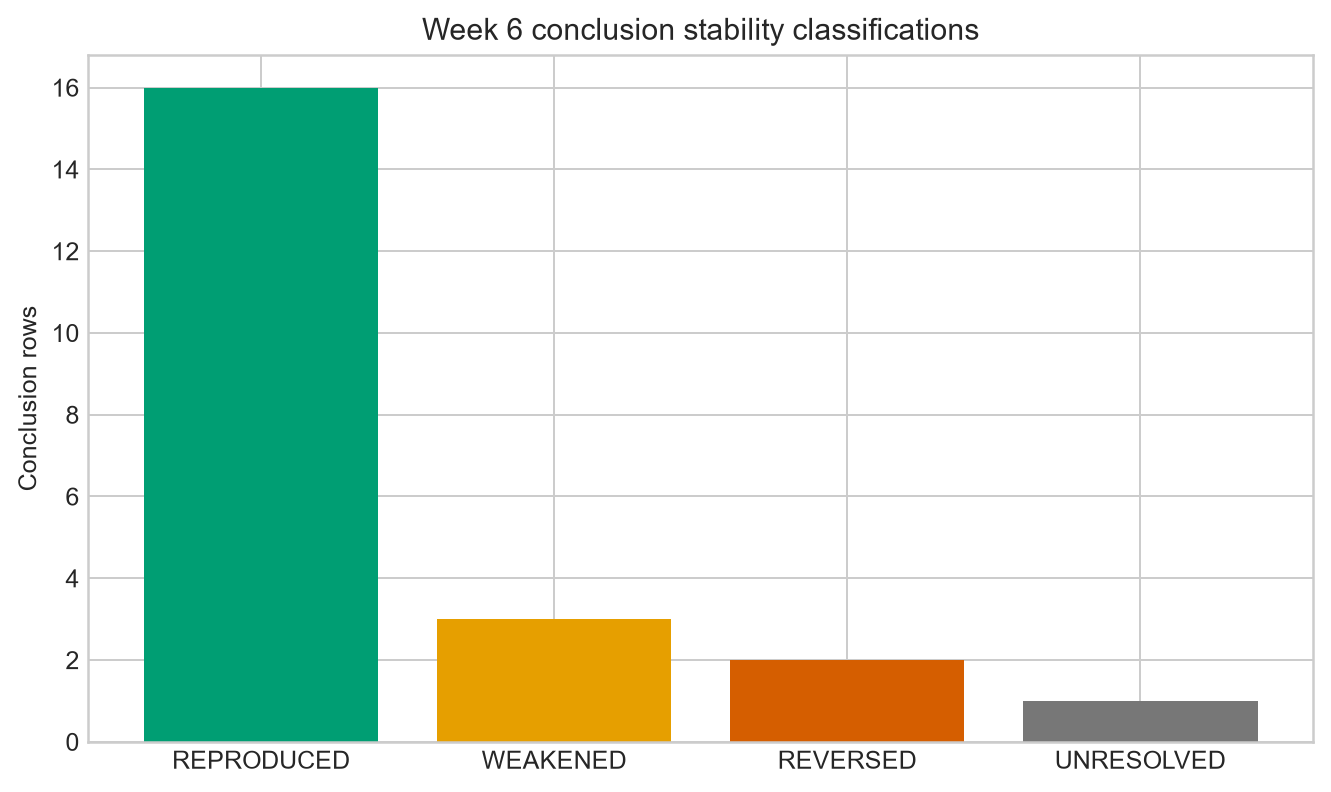

In [14]:
conclusions = pd.read_csv(OUT / "stability_conclusion_table.csv")
display(conclusions[["question", "target", "week6_conclusion", "new_data_evidence", "status", "evidence"]])
display(conclusions.groupby("status").size().rename("count").reset_index())
display(Image(filename=str(next((OUT / "figures").glob("*_conclusion_stability_counts.png"))), width=700))

**What did we observe?** The explicit evidence table contains {'REPRODUCED': 16, 'WEAKENED': 3, 'REVERSED': 2, 'UNRESOLVED': 1}. These labels separate observed model ranking from interpretation and leave genuinely mixed evidence unresolved.

## 15. Validation and hard stop

**What are we doing?** Display every automatic validation and requirement mapping, then assert the Phase 3 scope boundary.  
**Why?** Scientific conclusions are usable only if population, folds, metrics, artifacts, and notebook execution reconcile.  
**What question does this answer?** Did the full Phase 3 satisfy its requested checks without beginning later Week 7 work?  
**What would be suspicious?** A failed validation, missing output, stored notebook error, modified label, silent row removal, classifier, active-learning, or level-set artifact.

In [15]:
validation = pd.read_csv(OUT / "validation_results.csv")
checklist = pd.read_csv(OUT / "requirement_checklist.csv")
manifest = pd.read_csv(OUT / "output_manifest.csv")
kinetic_scope = pd.read_csv(OUT / "kinetic_energy_scope_caution.csv")
display(validation)
display(validation.groupby("status").size().rename("count").reset_index())
display(checklist)
display(kinetic_scope)
assert not validation["status"].eq("FAIL").any()
assert not population["source_label_modified"].astype(bool).any()
assert not population["simulation_silently_removed"].astype(bool).any()
assert not any(configuration["scope"].values())
display(Markdown(f"**Manifest:** {len(manifest)} files are recorded under the Phase 3 output root."))

,validation_id,requirement,status,evidence
0,V01,Immutable sph_v2 revision is exactly the corrected Phase 2 revision,PASS,revision=d69dac5bda8b622bc0de316b112815c6056c06ec
1,V02,Phase 3 starts from the current remote Week 7 Phase 1+2 head,PASS,codex/week7-phase1-2-sph-v2-audit@f26f0671dd59938a8111883398fe38afedb6915d
2,V03,Primary population is new-data only and old/new populations are never pooled,PASS,audit rows=165; model-ready rows=656; old primary rows=0
3,V04,Eligibility is derived only from corrected Phase 2 readiness fields and finite saved targets,PASS,"eligible counts={""depth"":164,""kinetic_energy"":164,""total_height"":164,""width"":164}"
4,V05,No simulation-identifier exclusion list is hard-coded,PASS,population membership follows readiness masks; no identifier exclusion constant exists
5,V06,T0 target values are copied exactly from corrected Phase 2 and are not redefined,PASS,four saved Phase 2 T0 columns matched exactly; raw windows used only for Method C uncertainty verification
6,V07,ST is substrate temperature with the Phase 1/2 unit K,PASS,ST=substrate temperature [K]
7,V08,Only the four requested physical responses are primary targets,PASS,"targets=[""depth"",""kinetic_energy"",""total_height"",""width""]"
8,V09,The complete 165-row new-data label/audit population is retained,PASS,audit rows=165; incomplete rows retained=1
9,V10,No label is modified and no simulation is silently removed,PASS,source label flags and Phase 3 prediction flags are all false


,status,count
0,PASS,24


,requirement_id,requirement,status,notebook_section,output_artifact,validation_ids
0,P3-01,Exact remote Week 7 base head and immutable sph_v2 revision recorded,PASS,Notebook §1,phase3_configuration.json,V01;V02
1,P3-02,Complete new-data audit population retained; readiness fields select each regression population,PASS,Notebook §2,model_ready_population.csv; model_ready_population_long.csv,V03;V04;V05;V09
2,P3-03,Executable Week 6 modelling protocol traced before fitting,PASS,Notebook §3,week6_model_traceability.csv,V02
3,P3-04,Exactly four saved Phase 2 T0 targets and P/VX/LS/ST inputs used,PASS,Notebook §§2–4,model_ready_population_long.csv,V06;V07;V08
4,P3-05,"Mean, Linear Ridge and degree-2 Polynomial Ridge evaluated by exact outer LOO",PASS,Notebook §5,fold_level_predictions.csv; model_metric_table.csv,V11;V12;V14
5,P3-06,"RBF, Matérn 3/2 and Matérn 5/2 GP candidates reproduce Week 6 settings",PASS,Notebook §6,kernel_comparison.csv; week6_model_traceability.csv,V11;V12
6,P3-07,"Numerical jitter, shared learned nugget and heteroskedastic-alpha methods compared",PASS,Notebook §7,noise_treatment_comparison.csv; target_summary_uncertainty.csv,V16;V17
7,P3-08,One explicit row is retained for every expected held-out prediction or fit failure,PASS,Notebook §8,fold_level_predictions.csv,V11;V13
8,P3-09,Median-scale relative MAE/RMSE are primary percentage metrics,PASS,Notebook §9,relative_error_table.csv,V14;V15
9,P3-10,"Observed/predicted, residual, scale-error, calibration and model comparison plots exist",PASS,Notebook §§10–12,figure_manifest.csv,V19


,experiment_name,max_kinetic_energy_nJ,T0_kinetic_energy_nJ,T0_kinetic_energy_percentile,T0_extreme_threshold_q3_plus_3iqr_nJ,T0_kinetic_energy_suspicious_by_q3_plus_3iqr,phase3_action,row_removed,maximum_kinetic_energy_analysis_in_scope,dataset_revision
0,P-336p384535968_VX-0p857000372961_LS-5p14827567032e-05_ST-367p720955238_M-TI64_XI-0p0002_XF-0p0014_XL-0p00...,198078.1,4.093987,64.634146,11.617693,False,maximum-energy anomaly recorded as out of Phase 3 scope; T0 row retained,False,False,d69dac5bda8b622bc0de316b112815c6056c06ec


**Manifest:** 175 files are recorded under the Phase 3 output root.

**What did we observe?** The full analysis stops here. No Keyhole classifier, feature-effect or causal interpretation, T0-versus-maximum target decision, extreme-event classifier, active learning, level-set estimation, acquisition change, or pooled production model has run.